# First Linear Checkpoint: Linear Modeling Baseline

This notebook is the educational entrypoint for the first modeling-stage checkpoint. It runs the reproducible script pipeline, then walks through the research design, chronological split, feature-only main model, historical persistence baselines, a persistence-augmented comparison model, missingness diagnostics, rolling-origin confirmation, robustness checks, mechanism submodels, and coefficient interpretation.

Teaching scaffold used throughout: **Question -> Concept -> Output -> How to read -> Takeaway**. The notebook should explain how to read each result, while reusable modeling and verification logic stays in `3_models/scripts/`.


## Learning Goals

By the end of this notebook, you should be able to explain:

1. Why this is a **First Linear Checkpoint**, not the final forecasting claim.
2. Why the primary model is feature-only rather than silently mixing lagged target history into the main predictor set.
3. How the teacher-confirmed chronological 80/10/10 split avoids random row-level time leakage.
4. Why historical target baselines are necessary before making any forecasting claim.
5. How to read `history_delta_summary`: positive delta MAE means the feature-only model trails a prediction-safe historical baseline.
6. How the confirmatory rolling-origin check distributes held-out blocks through time while keeping validation inside each pre-test window.
7. Why predictor missingness is preserved in the input, imputed inside the sklearn pipeline, and tested with both complete-case and `missingness_indicator_refit` sensitivity.
8. How year-level and target-quantile error decomposition show whether aggregate MAE hides high-innovation-country failures.
9. How to read MAE, RMSE, out-of-sample R2, Spearman rank correlation, robustness checks, and standardized coefficients without turning prediction results into causal claims.


## Optional Colab Setup

In [1]:
# Local runs skip this setup branch.
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print('Clone or upload the repository, then set PROJECT_ROOT = Path("/content/env-innovation-prediction") before continuing.')
else:
    print('Local run detected; setup skipped.')

Local run detected; setup skipped.


## Run the Reproducible Pipeline

The notebook does not duplicate modeling logic. It imports `run_modeling.py`, executes the same pipeline that can be run from the terminal, and then displays the generated tables and figures.

In [2]:
from pathlib import Path
import sys
import time

import pandas as pd
from IPython.display import Image, Markdown, display

_project_root_override = globals().get('PROJECT_ROOT')
if _project_root_override is not None:
    PROJECT_ROOT = Path(_project_root_override).resolve()
else:
    PROJECT_ROOT = Path.cwd().resolve()
    while PROJECT_ROOT.name != 'env-innovation-prediction' and PROJECT_ROOT != PROJECT_ROOT.parent:
        PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / '3_models' / 'scripts' / 'run_modeling.py').exists():
    raise FileNotFoundError(f'Could not find modeling scripts under PROJECT_ROOT={PROJECT_ROOT}')

SCRIPT_DIR = PROJECT_ROOT / '3_models' / 'scripts'
if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))

from run_modeling import run_linear_modeling, verify_generated_artifacts

run_started_at = time.time()
results = run_linear_modeling()
figure_paths = results['figure_paths']

def show_figure(name: str) -> None:
    display(Image(filename=figure_paths[name]))

display(Markdown(f"**Best validation model:** `{results['best_model']}`"))


**Best validation model:** `lasso_alpha_1`

## Step 1: Data Contract and Specification Registry

**Question -> Concept -> Output -> How to read -> Takeaway**

**Question.** What exactly is being modeled, and which protocol did we commit to before reading test results?

**Concept.** The first baseline uses the active v2 no-imputation main panel. The primary target is `env_patent_share_inventions`, and the primary features are the nine `*_lag1_3_mean` predictors. The panel already drops rows with missing target values; predictor missingness is intentionally preserved so that imputation can be fit inside the training pipeline rather than before the split.

**Output.** The sample summary and specification registry below are the audit trail: target, lag scheme, sample rule, imputation rule, model family, and validation selection metric.

**How to read.** Start with `split`, `year_start`, `year_end`, `rows`, `countries`, `imputation_rule`, and `selection_metric`. These columns tell you what evidence each later table is allowed to support.

**Takeaway.** This is a reproducible first checkpoint with a predeclared feature-only main specification, not a post-test search for the best story.


In [3]:
display(results['sample_summary'])
display(results['specification_registry'])
pd.DataFrame({'feature': results['feature_columns']})


,panel_id,panel_label,panel_role,comparison_group,feature_set_role,target_column,lag_suffix,comparison_scope,split,year_start,year_end,years,rows,countries,target_non_missing,feature_columns,complete_feature_rows,any_feature_missing_rows
0,main,Main v2 model,main,None,None,env_patent_share_inventions,lag1_3_mean,own_sample_not_direct_ranking,train,1999,2018,20,2073,171,2073,8,1071,1002
1,main,Main v2 model,main,None,None,env_patent_share_inventions,lag1_3_mean,own_sample_not_direct_ranking,validation,2019,2020,2,227,130,227,8,158,69
2,main,Main v2 model,main,None,None,env_patent_share_inventions,lag1_3_mean,own_sample_not_direct_ranking,test,2021,2023,3,312,128,312,8,162,150
3,main,Main v2 model,main,None,None,env_patent_share_inventions,lag1_3_mean,own_sample_not_direct_ranking,all,1999,2023,25,2612,174,2612,8,1391,1221


,spec_id,target,lag_scheme,panel,sample_rule,imputation_rule,model_family,model_grid,scaling_note,selection_metric,primary_or_robustness,design_reason
0,main,env_patent_share_inventions,lag1_3_mean,2_data/processed/model_panels/v2/model_panel_m...,chronological_80_10_10_by_distinct_target_year,no_imputation_panel_with_train_fold_median_imp...,OLS_Ridge_Lasso_ElasticNet,"OLS; Ridge alpha=[0.1,1,10]; Lasso alpha=[0.00...",predictors are median-imputed and standardized...,validation_mae,main,active_v2_panel_or_mechanism_submodel
1,suba,env_patent_share_inventions,lag1_3_mean,2_data/processed/model_panels/v2/model_panel_s...,chronological_80_10_10_by_distinct_target_year,no_imputation_panel_with_train_fold_median_imp...,OLS_Ridge_Lasso_ElasticNet,"OLS; Ridge alpha=[0.1,1,10]; Lasso alpha=[0.00...",predictors are median-imputed and standardized...,validation_mae,mechanism_submodel,active_v2_panel_or_mechanism_submodel
2,subb,env_patent_share_inventions,lag1_3_mean,2_data/processed/model_panels/v2/model_panel_s...,chronological_80_10_10_by_distinct_target_year,no_imputation_panel_with_train_fold_median_imp...,OLS_Ridge_Lasso_ElasticNet,"OLS; Ridge alpha=[0.1,1,10]; Lasso alpha=[0.00...",predictors are median-imputed and standardized...,validation_mae,mechanism_submodel,active_v2_panel_or_mechanism_submodel
3,subc,env_patent_share_inventions,lag1_3_mean,2_data/processed/model_panels/v2/model_panel_s...,chronological_80_10_10_by_distinct_target_year,no_imputation_panel_with_train_fold_median_imp...,OLS_Ridge_Lasso_ElasticNet,"OLS; Ridge alpha=[0.1,1,10]; Lasso alpha=[0.00...",predictors are median-imputed and standardized...,validation_mae,mechanism_submodel,active_v2_panel_or_mechanism_submodel
4,robust_main_share_lag1_3_mean,env_patent_share_inventions,lag1_3_mean,2_data/processed/model_panels/v2/model_panel_m...,chronological_80_10_10_by_distinct_target_year,no_imputation_panel_with_train_fold_median_imp...,OLS_Ridge_Lasso_ElasticNet,"OLS; Ridge alpha=[0.1,1,10]; Lasso alpha=[0.00...",predictors are median-imputed and standardized...,validation_mae,robustness_primary_anchor,lag_timing_or_alternative_target_robustness
5,robust_main_share_lag1,env_patent_share_inventions,lag1,2_data/processed/model_panels/v2/model_panel_m...,chronological_80_10_10_by_distinct_target_year,no_imputation_panel_with_train_fold_median_imp...,OLS_Ridge_Lasso_ElasticNet,"OLS; Ridge alpha=[0.1,1,10]; Lasso alpha=[0.00...",predictors are median-imputed and standardized...,validation_mae,robustness_timing,lag_timing_or_alternative_target_robustness
6,robust_main_per_million_lag1_3_mean,env_patents_per_million,lag1_3_mean,2_data/processed/model_panels/robustness/env_p...,chronological_80_10_10_by_distinct_target_year,no_imputation_panel_with_train_fold_median_imp...,OLS_Ridge_Lasso_ElasticNet,"OLS; Ridge alpha=[0.1,1,10]; Lasso alpha=[0.00...",predictors are median-imputed and standardized...,validation_mae,robustness_target,lag_timing_or_alternative_target_robustness
7,robust_main_per_million_lag1,env_patents_per_million,lag1,2_data/processed/model_panels/robustness/env_p...,chronological_80_10_10_by_distinct_target_year,no_imputation_panel_with_train_fold_median_imp...,OLS_Ridge_Lasso_ElasticNet,"OLS; Ridge alpha=[0.1,1,10]; Lasso alpha=[0.00...",predictors are median-imputed and standardized...,validation_mae,robustness_target_timing,lag_timing_or_alternative_target_robustness
8,robust_main_share_skew_transformed_lag1_3_mean,env_patent_share_inventions,lag1_3_mean,2_data/processed/model_panels/v2/model_panel_m...,chronological_80_10_10_by_distinct_target_year,deterministic_skew_transform_then_train_fold_m...,OLS_Ridge_Lasso_ElasticNet,"OLS; Ridge alpha=[0.1,1,10]; Lasso alpha=[0.00...",predictors are median-imputed and standardized...,validation_mae,robustness_transform,skewed_predictor_scale_robustness_before_nonli...


,feature
0,renewable_energy_share_lag1_3_mean
1,wgi_regulatory_quality_lag1_3_mean
2,co2_per_capita_ar5_lag1_3_mean
3,fdi_net_inflows_lag1_3_mean
4,env_technology_rta_lag1_3_mean
5,trade_openness_lag1_3_mean
6,inflation_lag1_3_mean
7,size_factor_lag1_3_mean


## Step 2: Chronological 80/10/10 Split

The split is made over distinct target years, not shuffled rows. For the 1999-2023 panel this gives training years 1999-2018, validation years 2019-2020, and test years 2021-2023. The final test block is the latest period and is not used to choose the model.

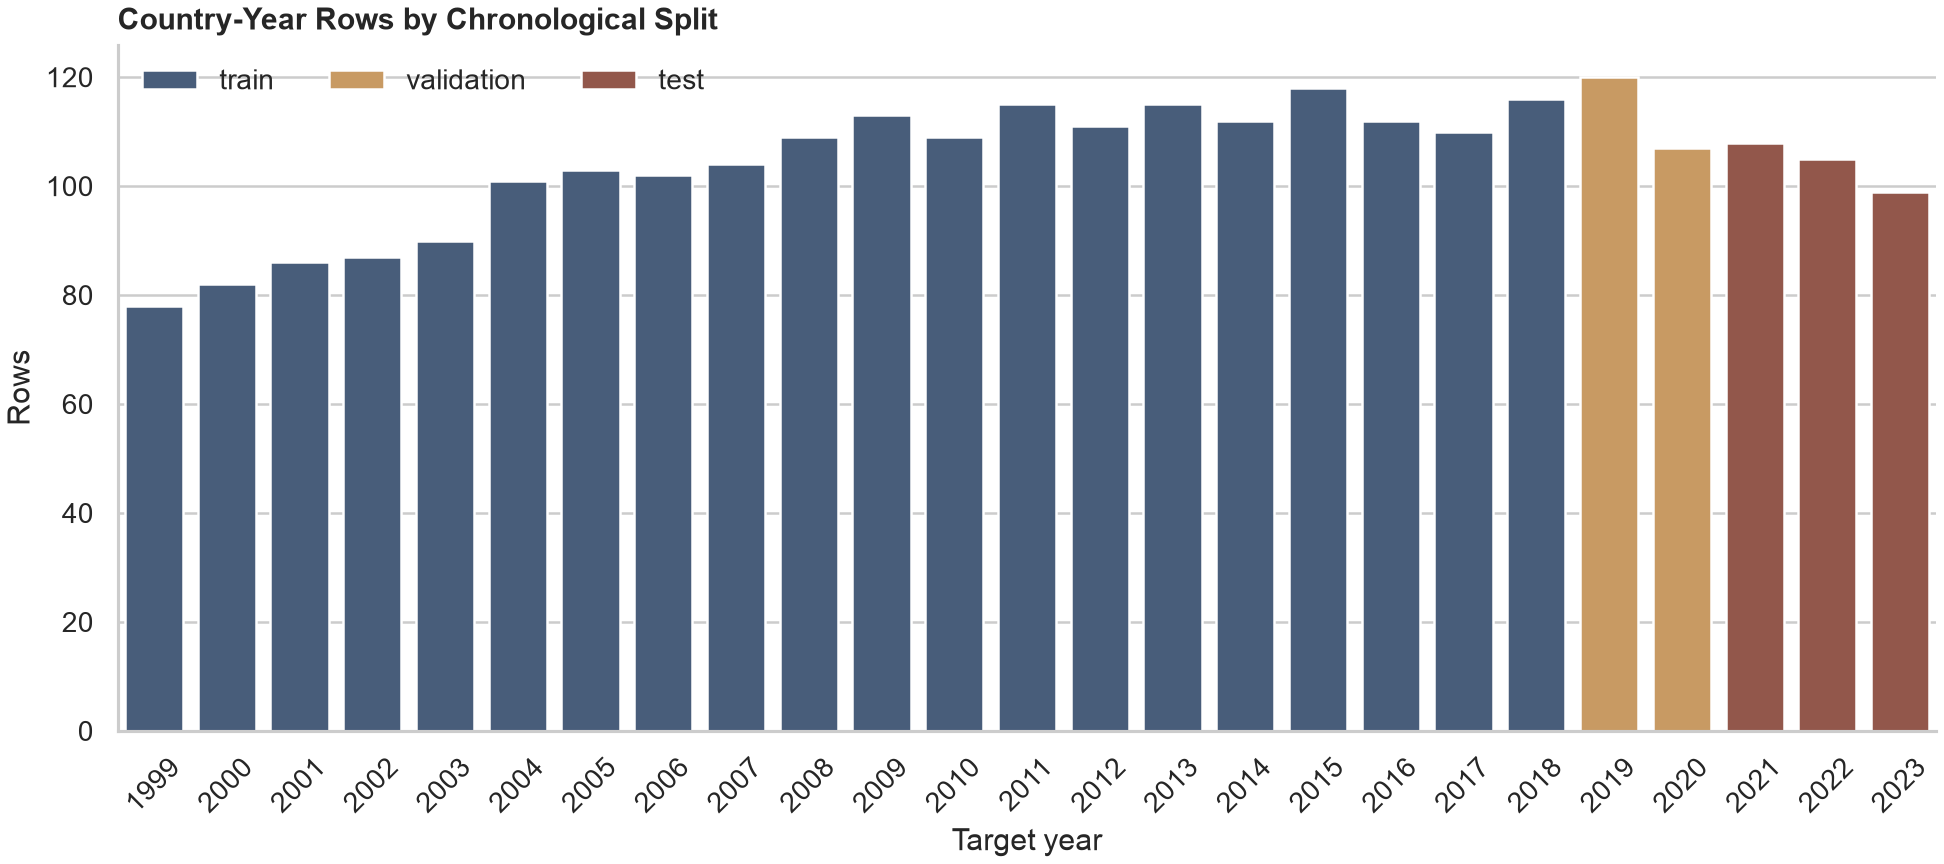

In [4]:
show_figure('split_rows')

## Step 3: Target Scale and Research Question

The target is right-skewed, so large innovation countries can dominate squared-error metrics. For this checkpoint we keep the target in original units because MAE remains interpretable. The more important design choice is conceptual: the main model is a feature-only main model, while target history is evaluated separately as a baseline and then as an explicit augmented comparison.


In [5]:
main_panel = results['experiments']['main']['panel']
target_column = results['experiments']['main']['target_column']
target_summary = main_panel[target_column].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]).to_frame('target')
display(target_summary)


,target
count,2612.000000
mean,0.939728
std,3.781098
min,0.000261
25%,0.003519
50%,0.018628
75%,0.149535
90%,1.116784
95%,3.484420
max,38.423080


## Step 4: Predictor Missingness and Train-Fold Imputation

The saved panel is a no-imputation panel. Missing predictor values remain as `NaN` until the sklearn pipeline is fit. Inside each candidate model, median imputation and scaling are fit on the training fold only, then reused for validation. After model selection, the final pipeline is refit on train plus validation before scoring the test block. The linear-interpolated panels are retrospective coverage sensitivity outputs only; they are not used in this modeling run.

The first figure shows the overall missing share by predictor among target-observed model rows. The next diagnostic goes further: it asks whether missing values in those rows mostly come from late-start coverage, early-ending series, bounded coverage windows, intermittent gaps, or countries with no observed values for a given predictor. Those patterns imply different interpretation risks.


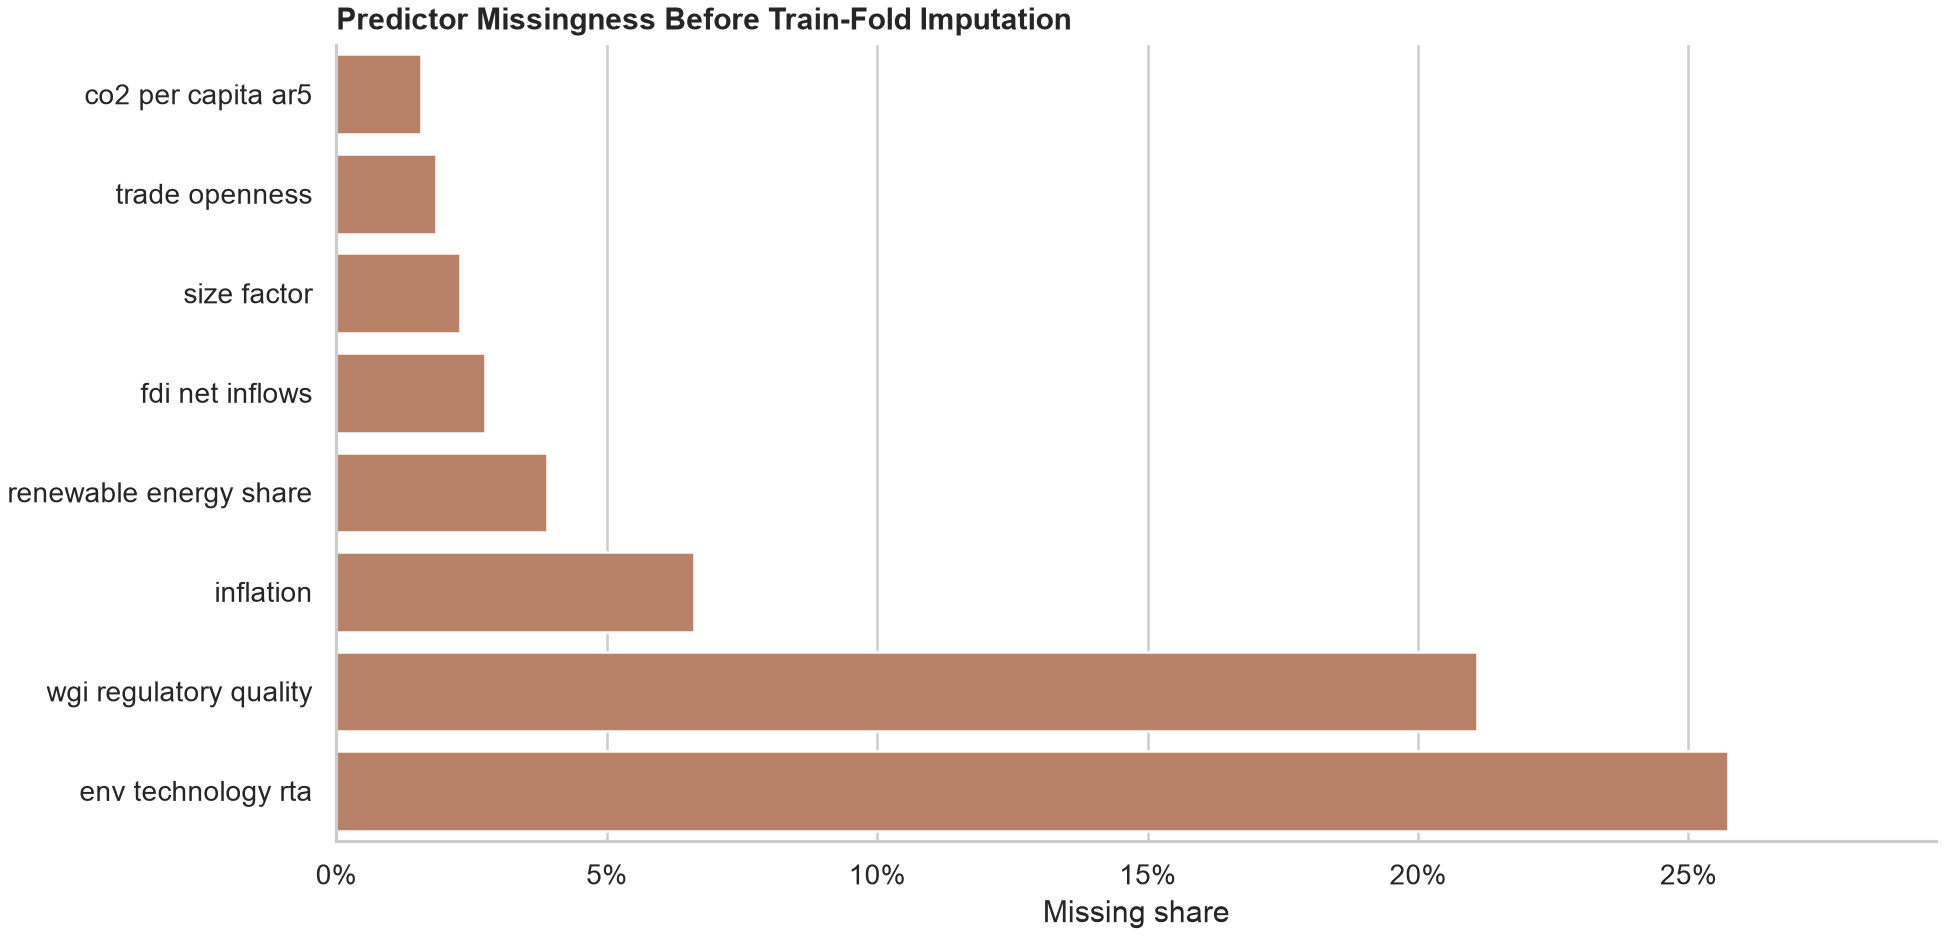

In [6]:
show_figure('feature_missingness')

## Step 5: Missingness Pattern Diagnostics

A single missing-share number can hide very different data-generating situations. These diagnostics classify each country-predictor sequence among target-observed model rows, not a fully balanced country-calendar-year grid. `total_years` counts rows present in the supervised model panel, while `calendar_year_span` records the span between the first and last target-observed row for that country.

Late-start coverage means observed predictor values begin after the country's early model rows. Early-ending coverage means observed values stop before the country's recent model rows. Bounded windows have both leading and trailing missing rows. Intermittent gaps mean observations disappear inside an otherwise covered country series; this category takes priority when a sequence also has leading or trailing missing rows. All-missing country-feature histories mean that the model can only use the train-fold median for that predictor-country combination.

This table and figure do not change the baseline model. They document why train-only median imputation is conservative and where future robustness checks, such as past-only carry-forward or source-specific exclusions, would be most relevant.


,feature,missing_share,complete_countries,late_start_countries,early_end_countries,bounded_coverage_window_countries,intermittent_gaps_countries,all_missing_countries
0,env_technology_rta_lag1_3_mean,0.257274,47,27,1,17,15,67
1,wgi_regulatory_quality_lag1_3_mean,0.210949,48,122,0,0,0,4
2,inflation_lag1_3_mean,0.066233,148,11,3,2,0,10
3,renewable_energy_share_lag1_3_mean,0.039051,80,0,92,1,0,1
4,fdi_net_inflows_lag1_3_mean,0.027565,161,4,2,0,0,7
5,size_factor_lag1_3_mean,0.022971,166,1,1,0,0,6
6,trade_openness_lag1_3_mean,0.018377,160,6,3,0,1,4
7,co2_per_capita_ar5_lag1_3_mean,0.015697,170,0,0,0,0,4


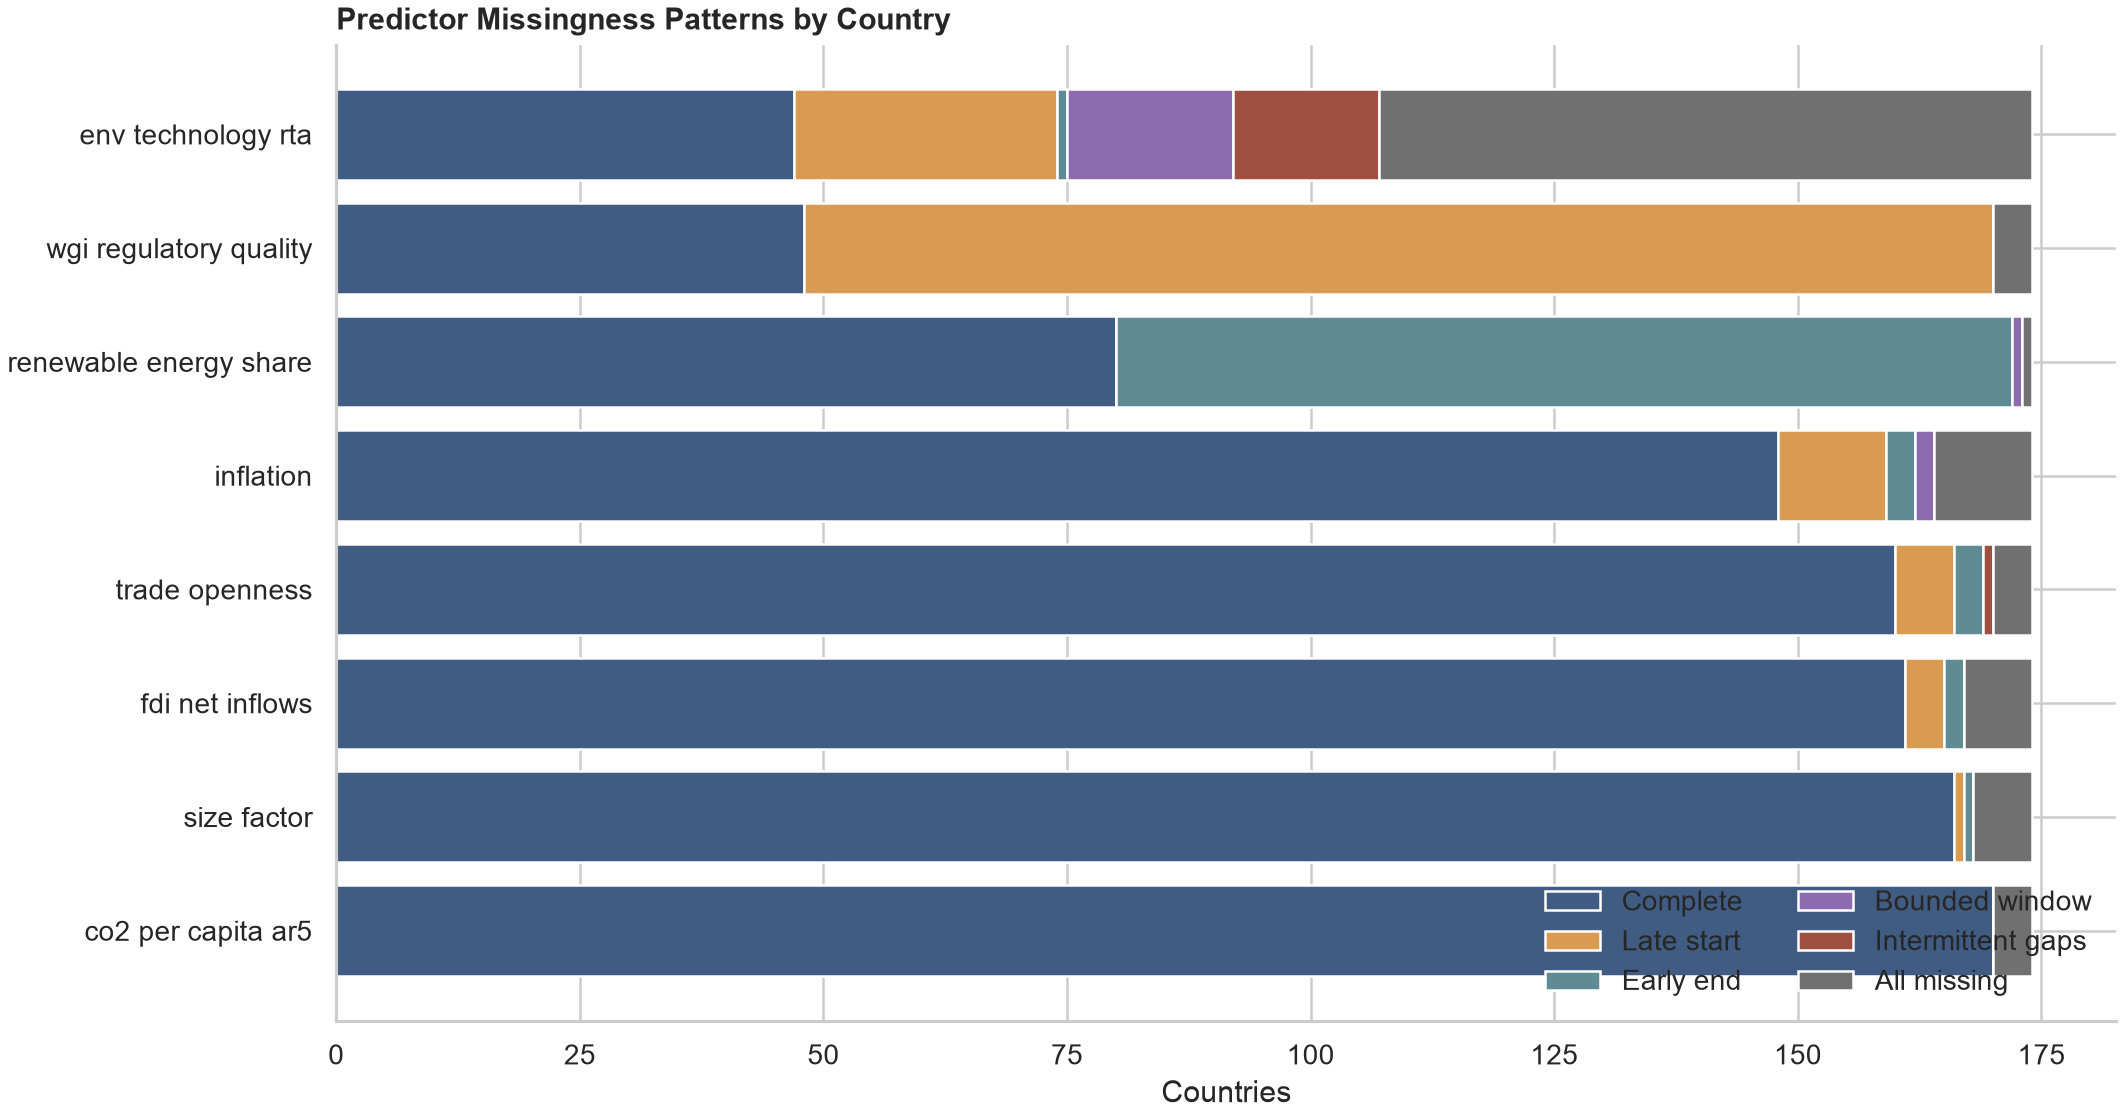

,feature,country_code,country_name,missingness_pattern,year_start,year_end,calendar_year_span,total_years,first_observed_year,last_observed_year,missing_years,internal_missing_years
1283,size_factor_lag1_3_mean,HKG,"Hong Kong SAR, China",all_missing,1999,2023,25,25,NaN,NaN,25,0
1049,inflation_lag1_3_mean,ARG,Argentina,late_start,1999,2023,25,25,2021.0,2023.0,22,0
491,co2_per_capita_ar5_lag1_3_mean,SRB,Serbia,all_missing,2003,2023,21,20,NaN,NaN,20,0
1209,inflation_lag1_3_mean,VEN,"Venezuela, RB",bounded_coverage_window,1999,2023,25,24,2012.0,2017.0,18,0
648,fdi_net_inflows_lag1_3_mean,PRI,Puerto Rico (US),all_missing,2004,2023,20,17,NaN,NaN,17,0
1170,inflation_lag1_3_mean,PRI,Puerto Rico (US),all_missing,2004,2023,20,17,NaN,NaN,17,0
869,env_technology_rta_lag1_3_mean,ZWE,Zimbabwe,bounded_coverage_window,1999,2023,25,16,2019.0,2019.0,15,0
559,fdi_net_inflows_lag1_3_mean,CUB,Cuba,all_missing,2001,2023,23,15,NaN,NaN,15,0
1081,inflation_lag1_3_mean,CUB,Cuba,all_missing,2001,2023,23,15,NaN,NaN,15,0
1208,inflation_lag1_3_mean,UZB,Uzbekistan,late_start,1999,2023,25,21,2014.0,2023.0,14,0


In [7]:
missingness_pattern_summary = results['missingness_pattern_summary']
missingness_pattern_detail = results['missingness_pattern_country_detail']

pattern_columns = [
    'feature',
    'missing_share',
    'complete_countries',
    'late_start_countries',
    'early_end_countries',
    'bounded_coverage_window_countries',
    'intermittent_gaps_countries',
    'all_missing_countries',
]
display(missingness_pattern_summary[pattern_columns])
show_figure('missingness_pattern_counts')

diagnostic_examples = (
    missingness_pattern_detail[
        missingness_pattern_detail['missingness_pattern'].isin(
            ['late_start', 'intermittent_gaps', 'bounded_coverage_window', 'all_missing']
        )
    ]
    .sort_values(['missing_years', 'feature', 'country_code'], ascending=[False, True, True])
    .head(15)
)
display(
    diagnostic_examples[
        [
            'feature',
            'country_code',
            'country_name',
            'missingness_pattern',
            'year_start',
            'year_end',
            'calendar_year_span',
            'total_years',
            'first_observed_year',
            'last_observed_year',
            'missing_years',
            'internal_missing_years',
        ]
    ]
)


## Step 6: Validation Chooses the Linear Candidate

**Question -> Concept -> Output -> How to read -> Takeaway**

**Question.** Which linear candidate is selected without looking at the final test block?

**Concept.** The training period fits each candidate linear model. The validation period chooses the candidate with the lowest MAE. This keeps the final test block reserved for one final evaluation after model choice.

**Output.** The table and figure rank linear candidates by validation MAE.

**How to read.** The smallest validation MAE wins; RMSE is a tie-break and a large-error warning, not the primary selector.

**Takeaway.** Selection is validation-driven, so later test and rolling-origin results can be interpreted as held-out checks rather than tuning feedback.


,rank,model,mae,rmse,oos_r2_vs_train_mean,spearman,is_selected
0,1,lasso_alpha_1,0.836675,1.822312,0.688384,0.863517,True
1,2,elastic_net_alpha_1_l1_0.8,0.858296,1.857172,0.676347,0.863517,False
2,3,elastic_net_alpha_1_l1_0.2,0.865928,1.927710,0.651295,0.809366,False
3,4,elastic_net_alpha_1_l1_0.5,0.889685,1.910898,0.657351,0.868339,False
4,5,lasso_alpha_0.1,0.919783,2.025992,0.614832,0.823524,False
5,6,elastic_net_alpha_0.1_l1_0.8,0.925864,1.990234,0.628308,0.810697,False
6,7,elastic_net_alpha_0.1_l1_0.5,0.941053,1.949117,0.643507,0.794392,False
7,8,elastic_net_alpha_0.1_l1_0.2,0.957681,1.919133,0.654391,0.770622,False
8,9,lasso_alpha_0.01,1.069133,2.102589,0.585157,0.782293,False
9,10,elastic_net_alpha_0.01_l1_0.8,1.069241,2.097798,0.587046,0.781308,False


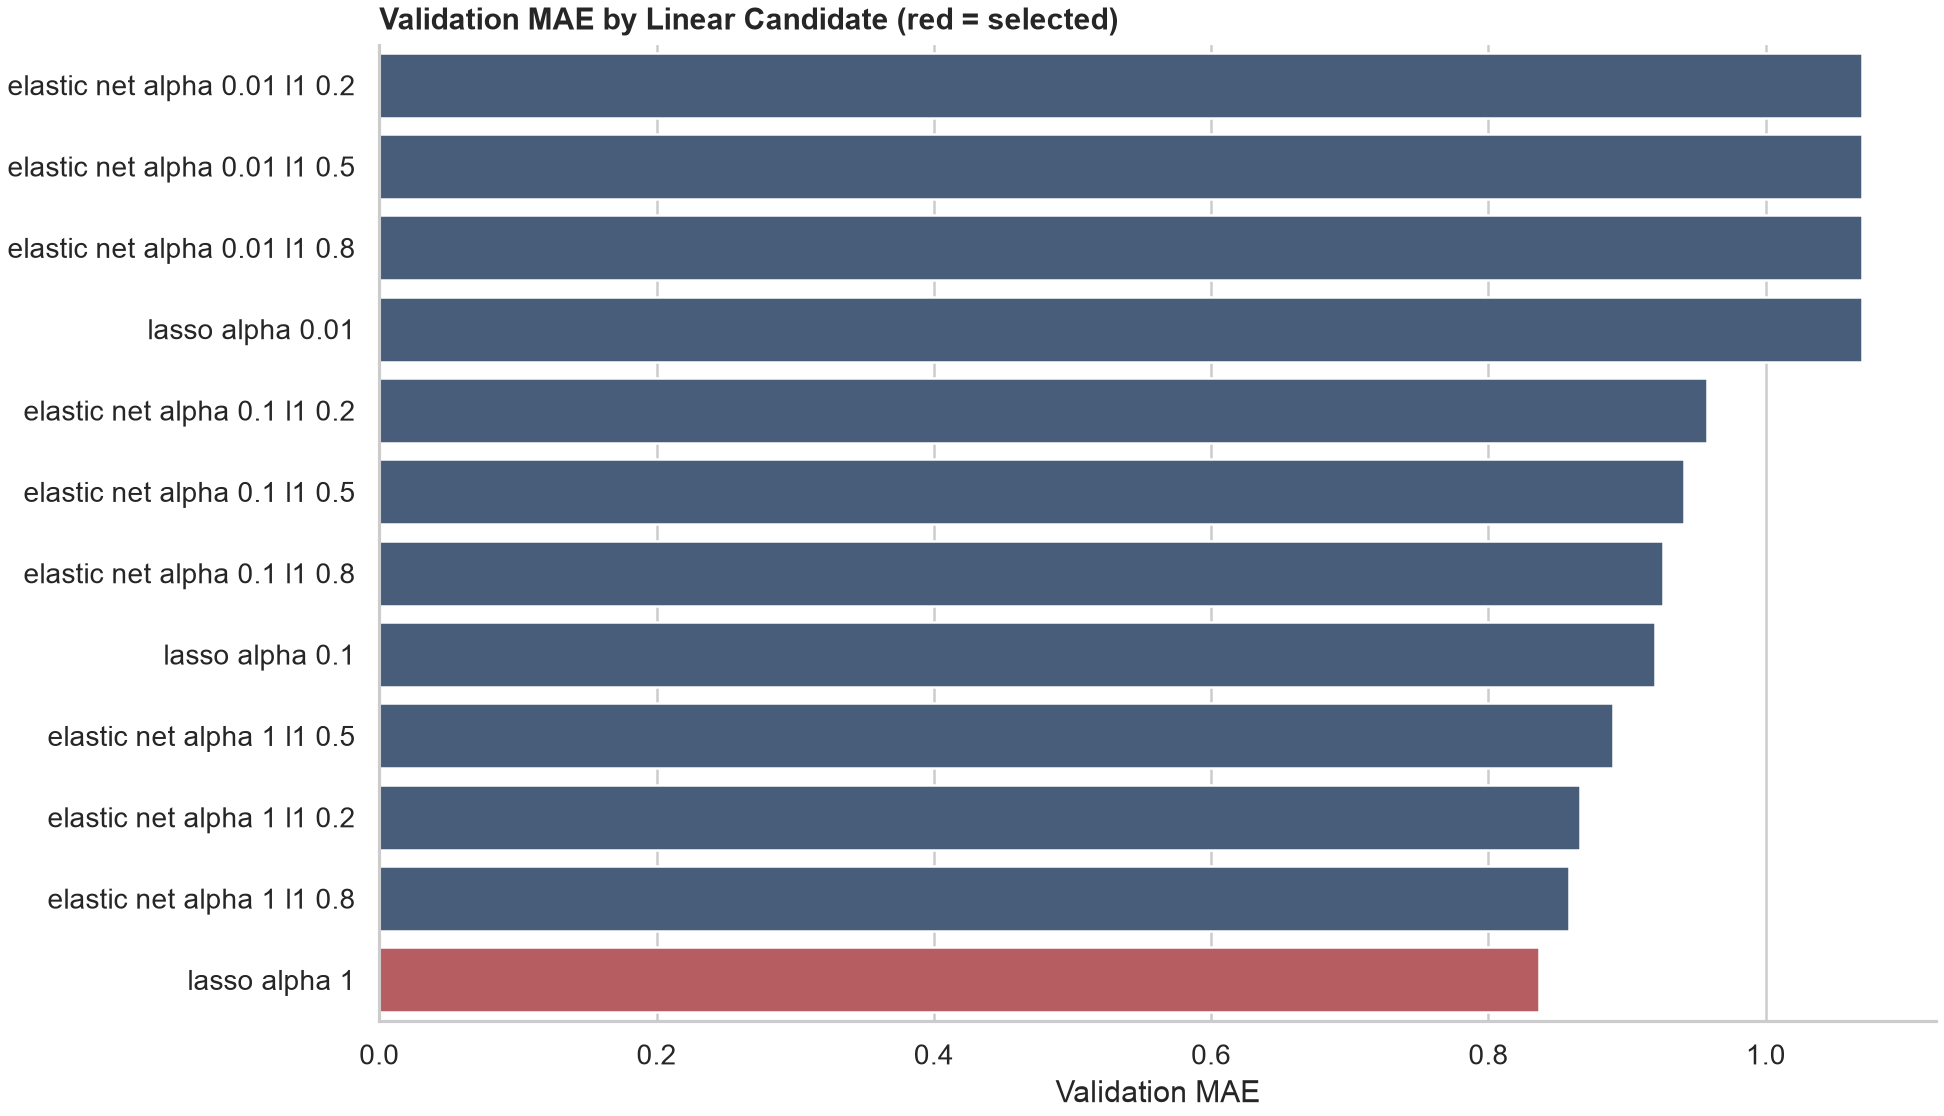

In [8]:
from model_visualization import build_candidate_comparison

# Rank every linear candidate by validation MAE; the pipeline selects the
# minimum-MAE model (is_selected=True) without touching the test block.
candidate_comparison = build_candidate_comparison(results['validation_metrics'])
display(candidate_comparison)
show_figure('validation_mae')


## Step 7: Final Test Evaluation

**Question -> Concept -> Output -> How to read -> Takeaway**

**Question.** How does the selected first-checkpoint linear model perform on the latest held-out block?

**Concept.** After validation selects the model, the selected pipeline is refit on train plus validation years and evaluated on 2021-2023. MAE is the headline metric because it is in target units. RMSE highlights large misses, out-of-sample R2 compares against the training-period mean, and Spearman checks rank ordering.

**Output.** The test table reports aggregate metrics, and the scatter plot shows observed versus predicted values.

**How to read.** A decent OOS R2 or Spearman does not prove the model beats country persistence; that question is answered by the historical-baseline delta table next.

**Takeaway.** Treat this as a first late-period stress check, not as the final proof of forecasting superiority.


,panel_id,panel_label,panel_role,comparison_group,feature_set_role,target_column,lag_suffix,model,split,n_train_validation,...,train_validation_rows,test_rows,train_validation_countries,test_countries,train_year_start,train_year_end,validation_year_start,validation_year_end,test_year_start,test_year_end
0,main,Main v2 model,main,None,None,env_patent_share_inventions,lag1_3_mean,lasso_alpha_1,test,2300,...,2300,312,174,128,1999,2018,2019,2020,2021,2023


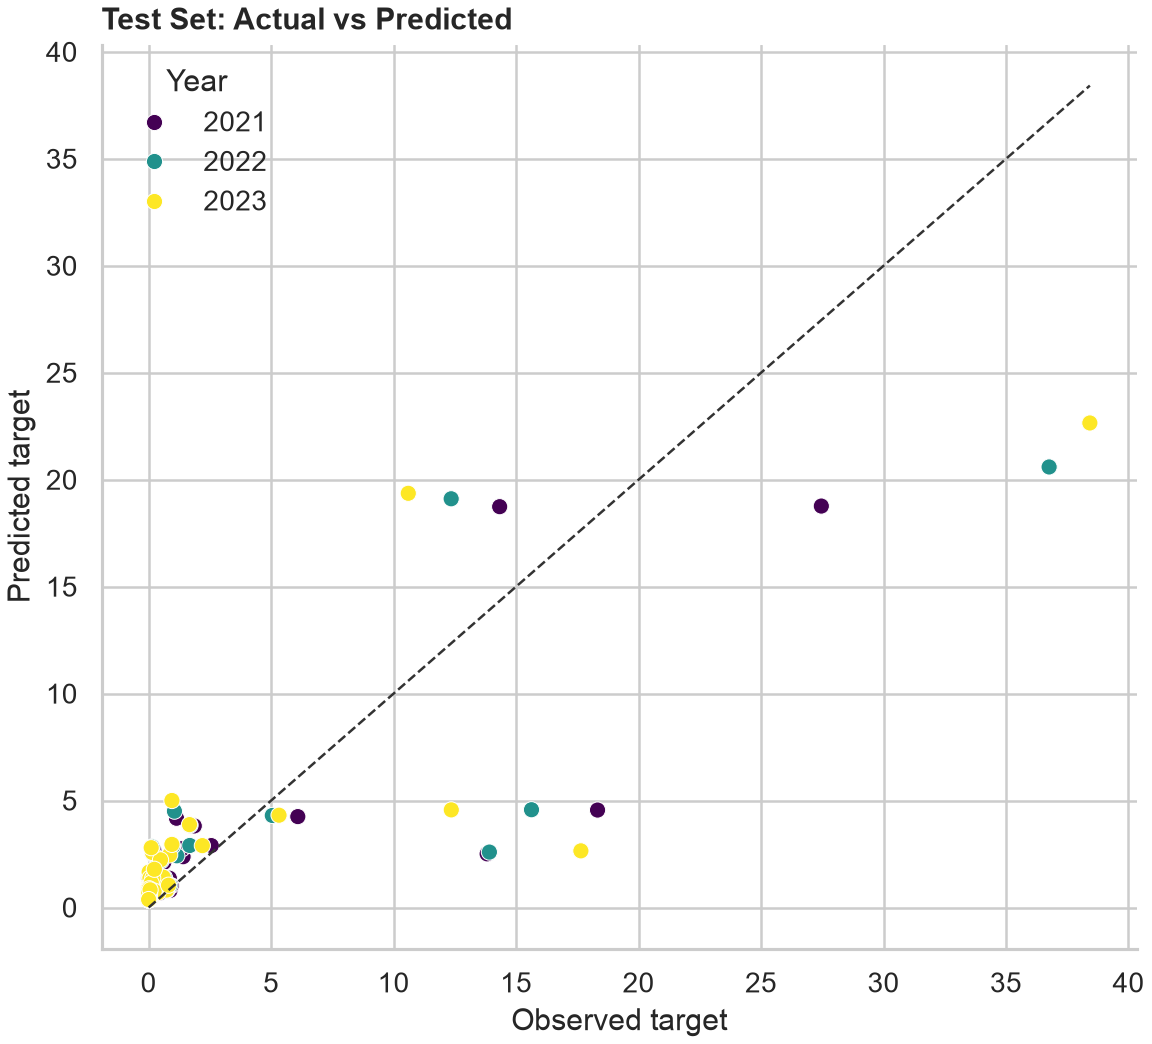

In [9]:
display(results['test_metrics'])
show_figure('actual_vs_predicted')

## Step 8: Persistence Baselines and History Delta

**Question -> Concept -> Output -> How to read -> Takeaway**

**Question.** Does the feature-only model beat simple prediction-safe target-history rules?

**Concept.** The strongest reviewer concern is whether the feature model improves on simple target-history forecasts. The baselines below use only target information available before the held-out test block: a global train+validation mean, a country train+validation mean, and a country last-pretest value held constant through 2021-2023.

**Output.** The first table shows baseline metrics. The `history_delta_summary` table then subtracts each historical baseline MAE from the selected feature-only model MAE.

**How to read.** Positive `delta_mae_selected_minus_baseline` means the feature-only model is worse than that historical baseline. Negative values would be needed before claiming that external predictors beat national historical persistence.

**Takeaway.** In this checkpoint, the narrative must remain conservative: the feature-only model is useful for interpretable associations and ranking diagnostics, not for claiming superiority over country history.


,model,split,prediction_rule,n_test,uses_test_labels,mae,rmse,oos_r2_vs_train_mean,spearman
0,country_last_pretest_holdconstant,test,country latest observed train+validation targe...,312,False,0.311860,1.553440,8.589848e-01,0.939671
1,country_train_validation_mean,test,"country mean target through validation period,...",312,False,0.679417,3.313285,3.585030e-01,0.941028
2,lasso_alpha_1,test,selected_model,312,False,1.063462,2.404000,6.622885e-01,0.845875
3,global_train_validation_mean,test,constant mean of train+validation targets,312,False,1.543124,4.136773,-7.483575e-07,NaN


,selected_model,baseline_model,baseline_prediction_rule,selected_mae,baseline_mae,delta_mae_selected_minus_baseline,selected_rmse,baseline_rmse,delta_rmse_selected_minus_baseline,selected_beats_baseline,professor_interpretation
0,lasso_alpha_1,country_last_pretest_holdconstant,country latest observed train+validation targe...,1.063462,0.311860,0.751602,2.404,1.553440,0.850560,False,The feature-only model trails this historical ...
1,lasso_alpha_1,country_train_validation_mean,"country mean target through validation period,...",1.063462,0.679417,0.384046,2.404,3.313285,-0.909285,False,The feature-only model trails this historical ...
2,lasso_alpha_1,global_train_validation_mean,constant mean of train+validation targets,1.063462,1.543124,-0.479662,2.404,4.136773,-1.732773,True,The feature-only model beats this historical b...


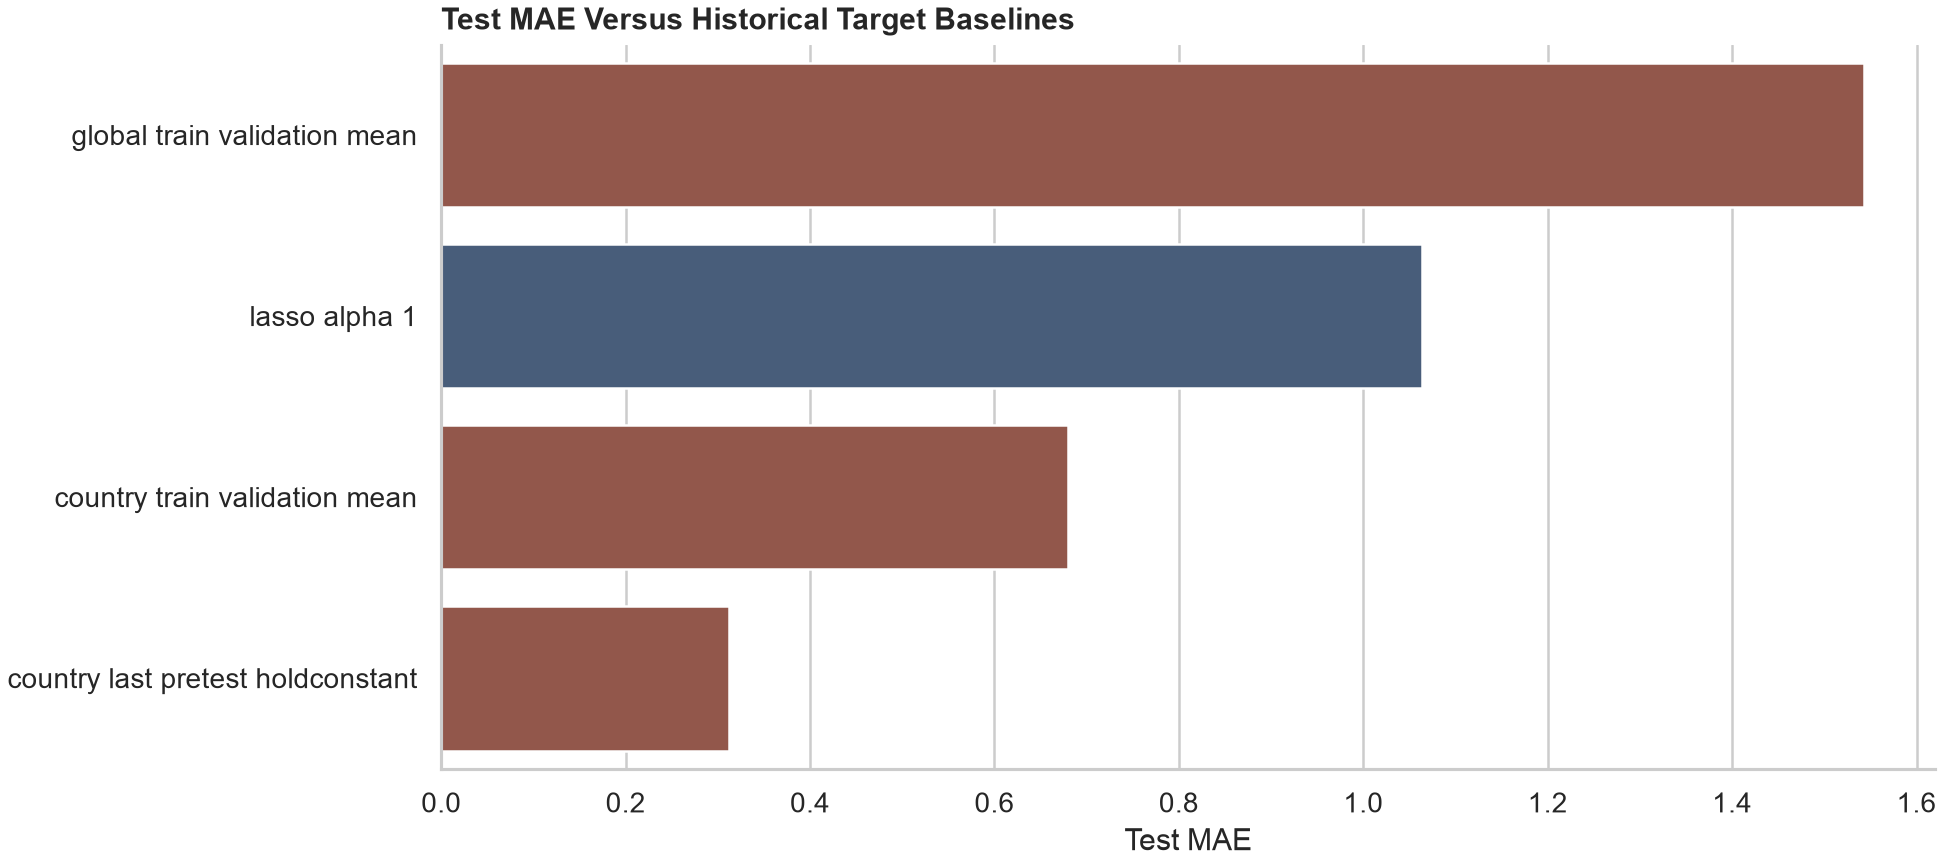

Feature-only test MAE is **1.063**. Against `country_last_pretest_holdconstant`, delta MAE is **0.752**. Positive delta means the feature-only model trails the history baseline, so do not claim that external predictors beat national historical persistence.

In [10]:
historical_baselines = results['historical_baselines']
history_delta_summary = results['history_delta_summary']
display(historical_baselines)
display(history_delta_summary)
show_figure('historical_baseline_mae')

selected_mae = history_delta_summary['selected_mae'].iloc[0]
best_delta = history_delta_summary.sort_values('baseline_mae').iloc[0]
display(Markdown(
    f"Feature-only test MAE is **{selected_mae:.3f}**. "
    f"Against `{best_delta['baseline_model']}`, delta MAE is "
    f"**{best_delta['delta_mae_selected_minus_baseline']:.3f}**. "
    "Positive delta means the feature-only model trails the history baseline, so do not claim that external predictors beat national historical persistence."
))


## Step 9: Persistence-Augmented Model

Now we answer the question directly: what happens if past target history is added as a predictor? We keep the primary model feature-only, then run a separate augmented comparison using `target_history_preblock`. This is a block-safe target history feature: validation years use only training-period target history, and test years use only train+validation target history. It never uses test-period labels inside the test block.

Read this as a decomposition: history-only shows national inertia; feature-only shows the external predictor baseline; feature plus history asks whether external predictors still matter after a persistence signal is available.


In [11]:
persistence_augmented_comparison = results['persistence_augmented_comparison']
display(
    persistence_augmented_comparison[
        [
            'model_stage',
            'model',
            'includes_main_predictors',
            'includes_target_history',
            'validation_mae',
            'test_mae',
            'test_rmse',
            'test_oos_r2_vs_train_mean',
            'test_spearman',
        ]
    ]
)

augmented_coefficients = results['persistence_augmented_coefficients']
display(
    augmented_coefficients[
        ['model', 'feature', 'coefficient', 'abs_coefficient']
    ].sort_values('abs_coefficient', ascending=False).head(8)
)

history_only = persistence_augmented_comparison[
    persistence_augmented_comparison['model_stage'].eq('history_only_baseline')
].iloc[0]
augmented = persistence_augmented_comparison[
    persistence_augmented_comparison['model_stage'].eq('persistence_augmented_linear')
].iloc[0]
feature_only = persistence_augmented_comparison[
    persistence_augmented_comparison['model_stage'].eq('feature_only_linear')
].iloc[0]
display(Markdown(
    f"Feature-only test MAE is **{feature_only['test_mae']:.3f}**; "
    f"persistence-augmented test MAE is **{augmented['test_mae']:.3f}**; "
    f"history-only persistence baseline MAE is **{history_only['test_mae']:.3f}**. "
    "This shows that target history is highly predictive, and that adding it changes the research question rather than simply improving the original main model."
))


,model_stage,model,includes_main_predictors,includes_target_history,validation_mae,test_mae,test_rmse,test_oos_r2_vs_train_mean,test_spearman
0,history_only_baseline,country_last_pretest_holdconstant,False,True,NaN,0.311860,1.553440,0.858985,0.939671
1,persistence_augmented_linear,lasso_alpha_0.1,True,True,0.150042,0.357995,1.506782,0.867328,0.917235
2,feature_only_linear,lasso_alpha_1,True,False,0.836675,1.063462,2.404000,0.662288,0.845875


,model,feature,coefficient,abs_coefficient
0,lasso_alpha_0.1,target_history_preblock,3.281806,3.281806
1,lasso_alpha_0.1,size_factor_lag1_3_mean,0.305794,0.305794
2,lasso_alpha_0.1,renewable_energy_share_lag1_3_mean,-0.000000,0.000000
3,lasso_alpha_0.1,wgi_regulatory_quality_lag1_3_mean,0.000000,0.000000
4,lasso_alpha_0.1,co2_per_capita_ar5_lag1_3_mean,0.000000,0.000000
5,lasso_alpha_0.1,fdi_net_inflows_lag1_3_mean,-0.000000,0.000000
6,lasso_alpha_0.1,env_technology_rta_lag1_3_mean,-0.000000,0.000000
7,lasso_alpha_0.1,trade_openness_lag1_3_mean,-0.000000,0.000000


Feature-only test MAE is **1.063**; persistence-augmented test MAE is **0.358**; history-only persistence baseline MAE is **0.312**. This shows that target history is highly predictive, and that adding it changes the research question rather than simply improving the original main model.

## Step 10: Failure Modes

After the persistence comparison, inspect where the feature-only model misses most. The table below lists the largest absolute test errors so limitations are visible rather than hidden behind aggregate metrics.


,rank,country_code,country_name,year,observed,prediction,error,absolute_error
0,1,CHN,China,2022,36.75972,20.595523,16.164197,16.164197
1,2,CHN,China,2023,38.42308,22.651915,15.771165,15.771165
2,3,KOR,"Korea, Rep.",2023,17.64583,2.650083,14.995747,14.995747
3,4,JPN,Japan,2021,18.32637,4.557419,13.768951,13.768951
4,5,KOR,"Korea, Rep.",2022,13.91118,2.592550,11.318630,11.318630
5,6,KOR,"Korea, Rep.",2021,13.81879,2.510099,11.308691,11.308691
6,7,JPN,Japan,2022,15.63018,4.572416,11.057764,11.057764
7,8,USA,United States,2023,10.59949,19.364445,-8.764955,8.764955
8,9,CHN,China,2021,27.46088,18.767895,8.692985,8.692985
9,10,JPN,Japan,2023,12.35528,4.565529,7.789751,7.789751


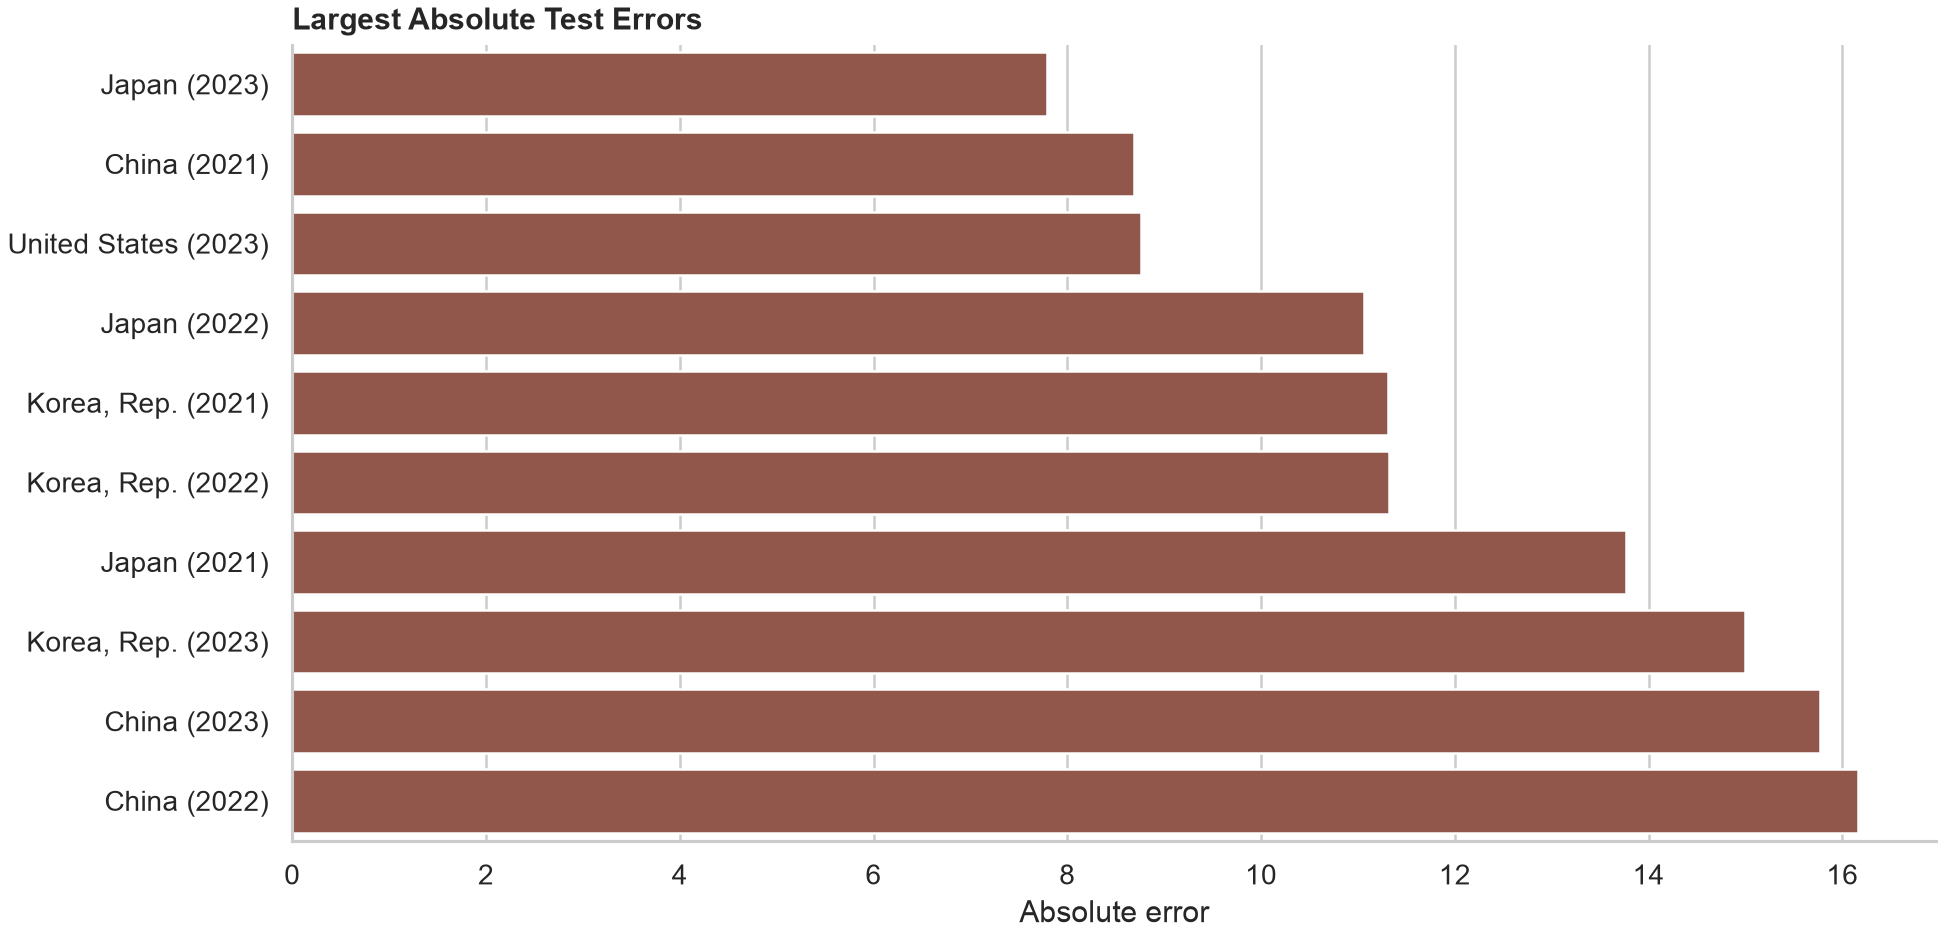

In [12]:
top_errors = results['top_errors'].head(10)
display(top_errors)
show_figure('top_absolute_errors')


## Step 10b: Error Decomposition by Year and Target Scale

**Question -> Concept -> Output -> How to read -> Takeaway**

**Question.** Are aggregate errors hiding specific years or high-target country-years where the model fails?

**Concept.** A single MAE can look acceptable while errors concentrate in recent years or in high-innovation observations. The script therefore writes year-level and target-quantile error summaries.

**Output.** `error_by_year` groups errors by test year. `error_by_target_quantile` groups the same test predictions by observed target quantile.

**How to read.** Compare MAE and RMSE across rows. Higher target quantiles with larger MAE mean the model struggles where environmental innovation shares are largest.

**Takeaway.** This is a failure-mode diagnostic, not a post-test rule for deleting countries or retuning the model.


In [13]:
display(results['error_by_year'])
display(results['error_by_target_quantile'])


,year,n_test,mae,rmse,mean_error,median_absolute_error
0,2021,108,0.953150,2.101787,-0.292266,0.448555
1,2022,105,1.082289,2.454836,-0.334012,0.469345
2,2023,99,1.163836,2.646270,-0.364558,0.522729


,target_quantile,n_test,target_min,target_max,mae,rmse,mean_error,median_absolute_error
0,Q1,78,0.000431,0.002322,0.409127,0.414469,-0.409127,0.388143
1,Q2,78,0.002336,0.016603,0.505725,0.548464,-0.505725,0.427429
2,Q3,78,0.016670,0.132606,0.695464,0.785891,-0.695464,0.619603
3,Q4,78,0.139793,38.423080,2.643533,4.693255,0.293300,1.212037


## Step 11: Missingness Sensitivity

**Question -> Concept -> Output -> How to read -> Takeaway**

**Question.** Are conclusions fragile because many predictor values are missing?

**Concept.** The main panel is a no-imputation source panel, but the model itself uses train-fold median imputation inside the sklearn pipeline. The complete-case rerun checks what happens after removing rows with any missing active predictor. The `missingness_indicator_refit` keeps all rows and adds one binary missingness indicator per active predictor, preserving the original train-fold imputation pipeline.

**Output.** The sensitivity table compares primary median-imputed, complete-case, and missingness-indicator runs. The indicator plan shows which binary features were added.

**How to read.** Compare rows, countries, test rows, and test MAE together. A lower MAE with far fewer rows is not automatically a better main model.

**Takeaway.** Missingness remains a substantive limitation; these checks qualify the interpretation rather than replacing the primary feature-only specification.


,analysis,panel_id,best_model,rows,countries,feature_columns,test_rows,test_countries,test_year_start,test_year_end,test_mae,test_rmse,test_oos_r2_vs_train_mean,test_spearman,comparison_note
0,primary_median_imputed_all_rows,main,lasso_alpha_1,2612,174,8,312,128,2021,2023,1.063462,2.404000,0.662288,0.845875,Primary model uses all rows with train-fold me...
1,complete_case_refit,main_complete_case,lasso_alpha_1,1391,99,8,162,84,2021,2023,1.266386,2.637712,0.657129,0.829870,Rows with any missing active predictor are dro...
2,missingness_indicator_refit,main_missingness_indicator,lasso_alpha_1,2612,174,16,312,128,2021,2023,1.063462,2.404000,0.662288,0.845875,Adds one binary missingness indicator per acti...


,source_feature,indicator_feature,missing_rows,missing_share,original_missing_values_preserved
0,renewable_energy_share_lag1_3_mean,missing__renewable_energy_share_lag1_3_mean,102,0.039051,True
1,wgi_regulatory_quality_lag1_3_mean,missing__wgi_regulatory_quality_lag1_3_mean,551,0.210949,True
2,co2_per_capita_ar5_lag1_3_mean,missing__co2_per_capita_ar5_lag1_3_mean,41,0.015697,True
3,fdi_net_inflows_lag1_3_mean,missing__fdi_net_inflows_lag1_3_mean,72,0.027565,True
4,env_technology_rta_lag1_3_mean,missing__env_technology_rta_lag1_3_mean,672,0.257274,True
5,trade_openness_lag1_3_mean,missing__trade_openness_lag1_3_mean,48,0.018377,True
6,inflation_lag1_3_mean,missing__inflation_lag1_3_mean,173,0.066233,True
7,size_factor_lag1_3_mean,missing__size_factor_lag1_3_mean,60,0.022971,True


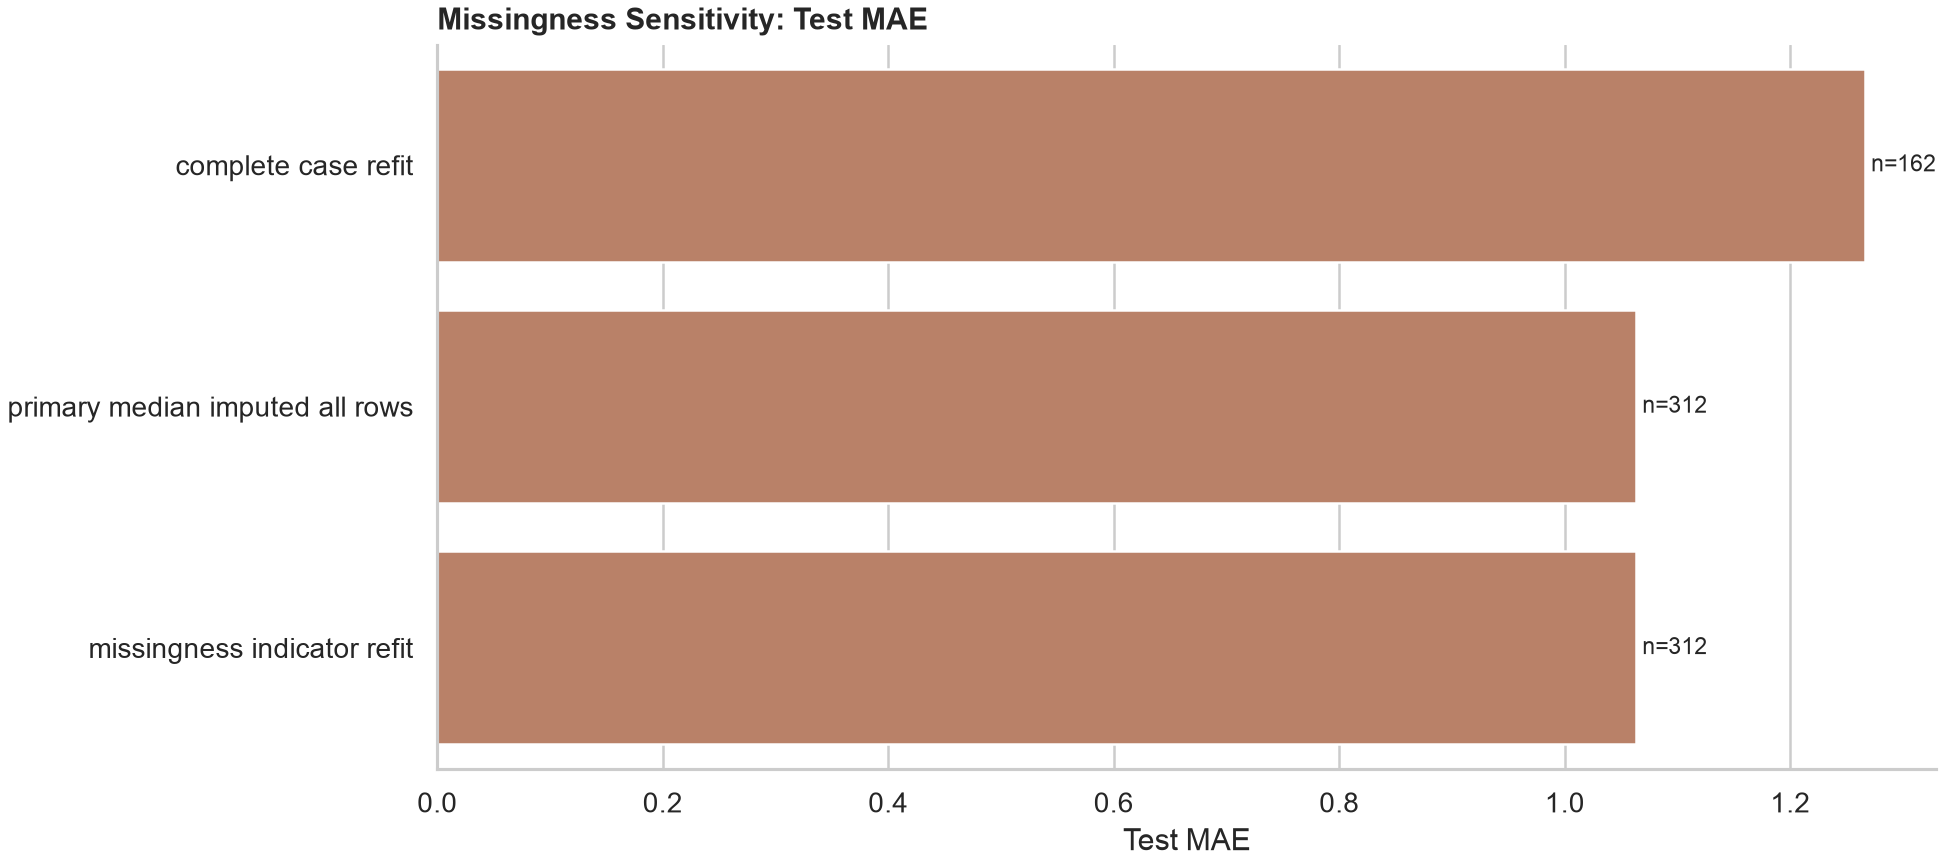

In [14]:
missingness_sensitivity = results['missingness_sensitivity']
display(missingness_sensitivity)
display(results['missingness_indicator_plan'])
show_figure('missingness_sensitivity_mae')


## Step 12: Linear Robustness Pack

Robustness here means checking whether the same qualitative conclusion survives a small, protocol-bounded set of sensitivity settings. We keep the teacher-confirmed chronological 80/10/10 split and the same validation-only model-selection rule, then vary three design dimensions: **common-sample lag1 versus lag1_3_mean** predictor timing, skew-transformed main predictors, and the alternative target `env_patents_per_million`.

This section is intentionally still linear. The candidate family now includes ordinary least squares, Ridge, Lasso, and ElasticNet. The finite regularization grid is shown in the specification registry. Predictors are standardized inside each pipeline, but the target is not standardized, so alpha values are target-scale dependent and should be read as a limited exploratory grid rather than a fully tuned regularization protocol.

The lag1 rows are common-sample timing sensitivities: they reuse the same generated panels and change only which lagged predictor columns are selected. The main scientific question is not whether one row has the smallest raw MAE across different target units. The question is whether the selected linear feature model beats the strongest prediction-safe historical baseline within each target setting.


,robustness_id,target_column,lag_suffix,best_model,rows,countries,validation_mae,test_mae,best_historical_baseline_model,best_historical_baseline_mae,delta_test_mae_selected_minus_best_history,beats_best_historical_baseline
0,robust_main_share_lag1,env_patent_share_inventions,lag1,lasso_alpha_1,2612,174,0.833752,1.054674,country_last_pretest_holdconstant,0.31186,0.742814,False
1,robust_main_share_lag1_3_mean,env_patent_share_inventions,lag1_3_mean,lasso_alpha_1,2612,174,0.836675,1.063462,country_last_pretest_holdconstant,0.31186,0.751602,False
2,robust_main_share_skew_transformed_lag1_3_mean,env_patent_share_inventions,lag1_3_mean,lasso_alpha_1,2612,174,0.836675,1.063462,country_last_pretest_holdconstant,0.31186,0.751602,False
3,robust_main_per_million_lag1,env_patents_per_million,lag1,elastic_net_alpha_1_l1_0.8,2604,169,8.052719,7.496002,country_train_validation_mean,2.57279,4.923213,False
4,robust_main_per_million_lag1_3_mean,env_patents_per_million,lag1_3_mean,elastic_net_alpha_1_l1_0.8,2604,169,8.136095,7.663395,country_train_validation_mean,2.57279,5.090606,False


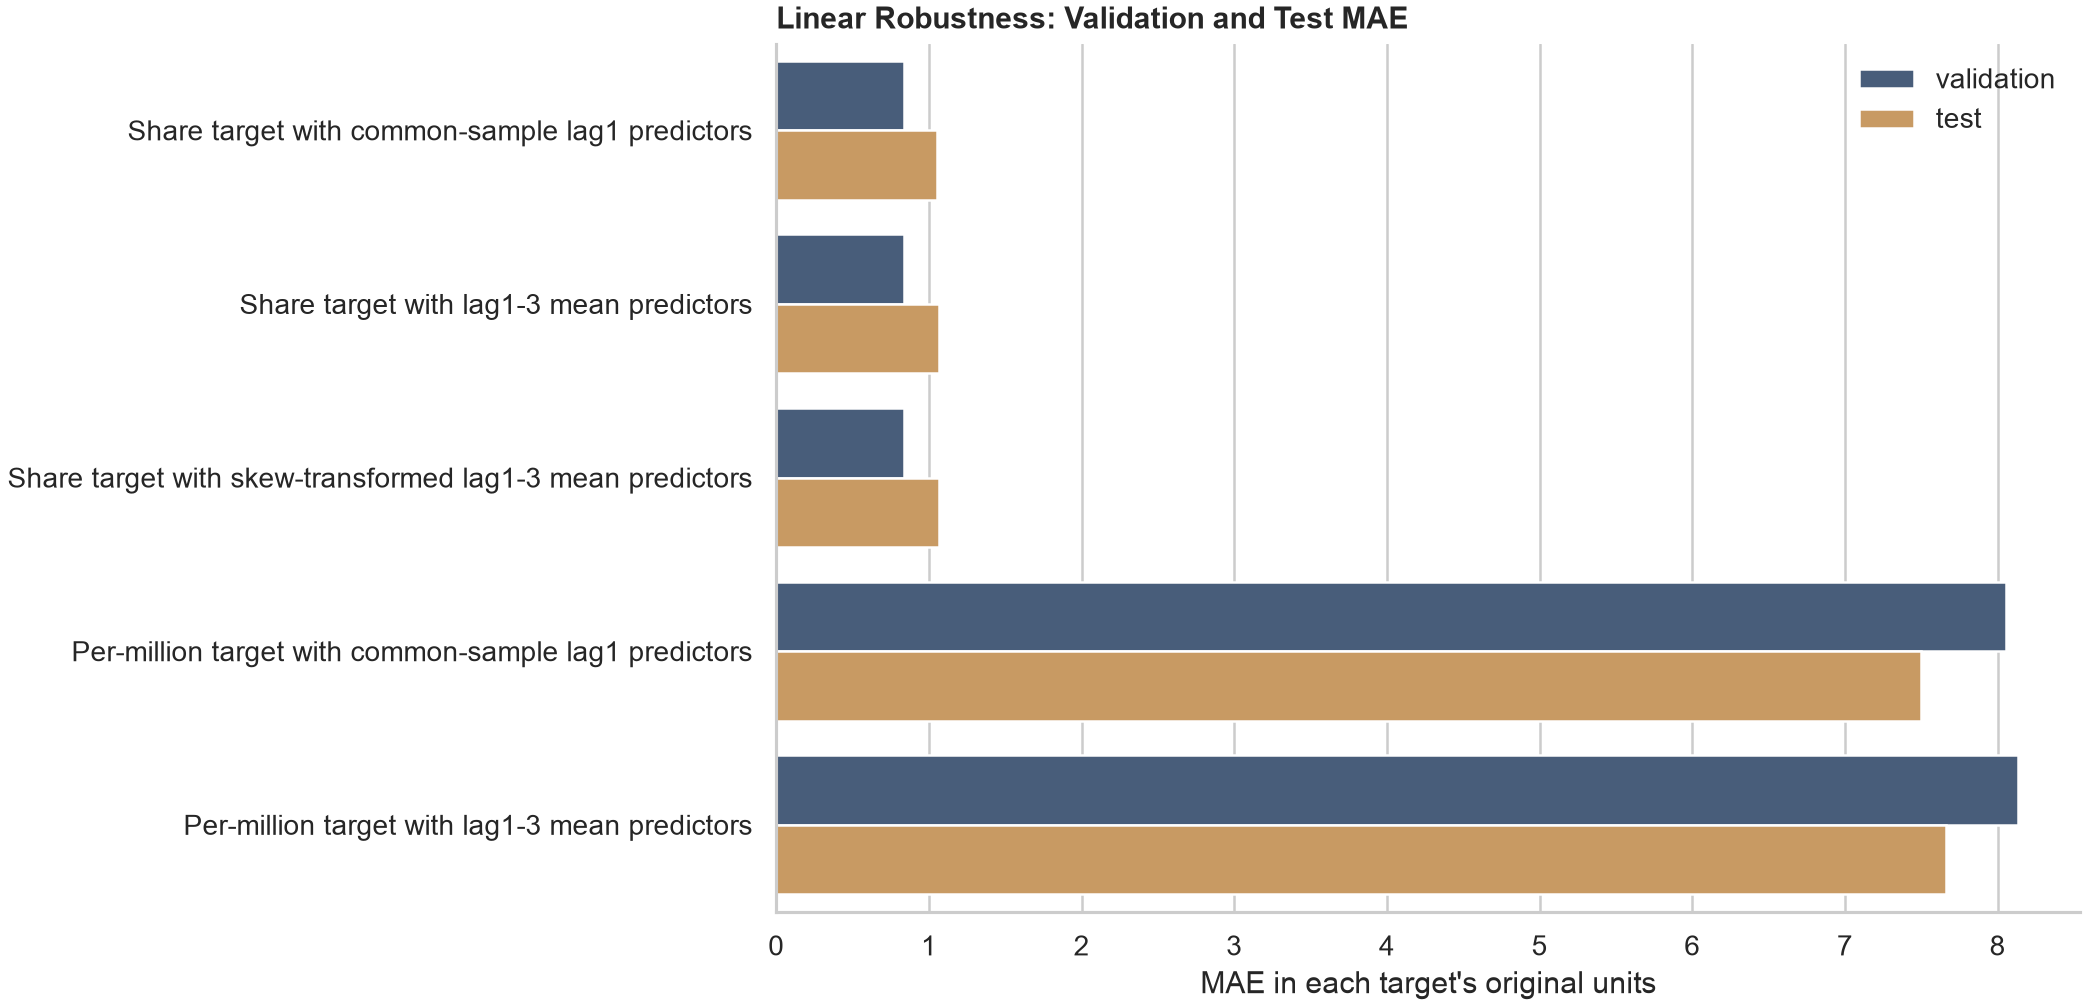

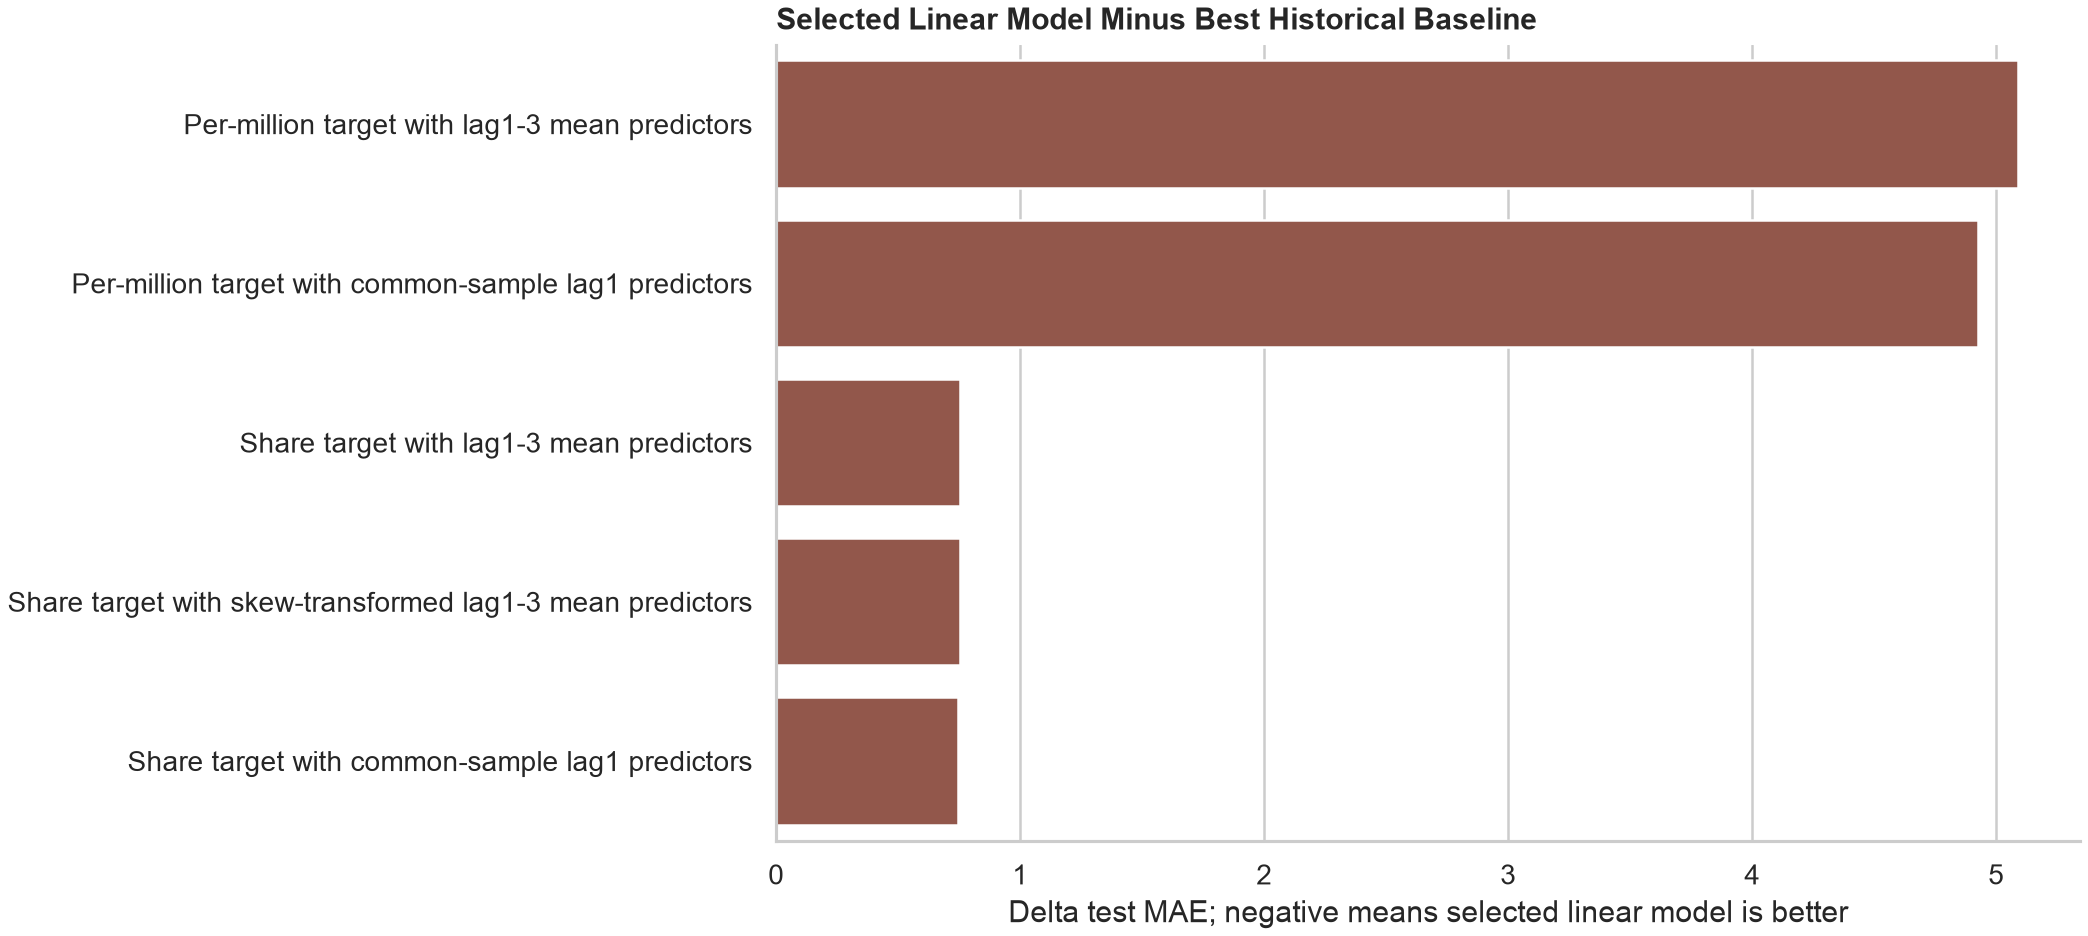

Robustness result: `0` of `5` protocol-bounded linear settings beat their strongest prediction-safe historical baseline. This supports reporting the feature models as interpretable association/ranking diagnostics rather than as superior short-horizon forecasts over national historical persistence.

In [15]:
robustness_summary = results['robustness_summary']
robustness_columns = [
    'robustness_id',
    'target_column',
    'lag_suffix',
    'best_model',
    'rows',
    'countries',
    'validation_mae',
    'test_mae',
    'best_historical_baseline_model',
    'best_historical_baseline_mae',
    'delta_test_mae_selected_minus_best_history',
    'beats_best_historical_baseline',
]
display(robustness_summary[robustness_columns])
show_figure('robustness_validation_test_mae')
show_figure('robustness_history_delta')

beats_history = int(robustness_summary['beats_best_historical_baseline'].sum())
total_settings = len(robustness_summary)
display(Markdown(
    f"Robustness result: `{beats_history}` of `{total_settings}` protocol-bounded linear settings "
    "beat their strongest prediction-safe historical baseline. "
    "This supports reporting the feature models as interpretable association/ranking diagnostics rather than "
    "as superior short-horizon forecasts over national historical persistence."
))


## Step 13: Skew-Transformed Linear Robustness

Standard scaling puts predictors on comparable units, but it does not make highly right-skewed variables approximately normal. This robustness check asks whether the feature-only linear model was mainly hurt by long-tailed predictor scales such as GDP, scientific articles, FDI, trade openness, CO2 per capita, manufacturing value added share, and inflation.

The transformations are deterministic and use no fitted information from validation or test labels. Positive right-skewed variables use `log1p`; signed variables with negative values use `asinh`; bounded or already near-symmetric variables stay on their original scale before the same median-imputation and StandardScaler pipeline. This makes the check a linear-model robustness step before moving to nonlinear models, not a replacement for the primary feature-only baseline.


In [16]:
skew_transform_plan = results['skew_transform_plan']
display(skew_transform_plan)

skew_id = 'robust_main_share_skew_transformed_lag1_3_mean'
primary_id = 'robust_main_share_lag1_3_mean'
skew_comparison = robustness_summary[
    robustness_summary['robustness_id'].isin([primary_id, skew_id])
].loc[:, [
    'robustness_id',
    'best_model',
    'validation_mae',
    'test_mae',
    'test_oos_r2_vs_train_mean',
    'test_spearman',
    'best_historical_baseline_model',
    'best_historical_baseline_mae',
    'beats_best_historical_baseline',
]]
display(skew_comparison)

primary_row = robustness_summary[robustness_summary['robustness_id'].eq(primary_id)].iloc[0]
skew_row = robustness_summary[robustness_summary['robustness_id'].eq(skew_id)].iloc[0]
display(Markdown(
    f"Skew-transform result: validation MAE changes from `{primary_row['validation_mae']:.3f}` "
    f"to `{skew_row['validation_mae']:.3f}`, and test MAE changes from `{primary_row['test_mae']:.3f}` "
    f"to `{skew_row['test_mae']:.3f}`. In this run, skew transformation does not rescue the "
    "feature-only linear model, so the next defensible step is to test nonlinear models as a separate "
    "model-family robustness stage rather than to relabel the transformed linear model as primary."
))


,panel_id,source_feature,model_feature,transformation,missing_values_preserved,rationale
0,robust_main_share_skew_transformed_lag1_3_mean,renewable_energy_share_lag1_3_mean,renewable_energy_share_lag1_3_mean,identity,True,kept on original scale before standardization ...
1,robust_main_share_skew_transformed_lag1_3_mean,wgi_regulatory_quality_lag1_3_mean,wgi_regulatory_quality_lag1_3_mean,identity,True,kept on original scale before standardization ...
2,robust_main_share_skew_transformed_lag1_3_mean,co2_per_capita_ar5_lag1_3_mean,skew_log1p__co2_per_capita_ar5_lag1_3_mean,log1p,True,positive right-skewed scale compressed before ...
3,robust_main_share_skew_transformed_lag1_3_mean,fdi_net_inflows_lag1_3_mean,skew_asinh__fdi_net_inflows_lag1_3_mean,asinh,True,signed right-skewed scale compressed while ret...
4,robust_main_share_skew_transformed_lag1_3_mean,env_technology_rta_lag1_3_mean,skew_log1p__env_technology_rta_lag1_3_mean,log1p,True,positive right-skewed scale compressed before ...
5,robust_main_share_skew_transformed_lag1_3_mean,trade_openness_lag1_3_mean,skew_log1p__trade_openness_lag1_3_mean,log1p,True,positive right-skewed scale compressed before ...
6,robust_main_share_skew_transformed_lag1_3_mean,inflation_lag1_3_mean,skew_asinh__inflation_lag1_3_mean,asinh,True,signed right-skewed scale compressed while ret...
7,robust_main_share_skew_transformed_lag1_3_mean,size_factor_lag1_3_mean,size_factor_lag1_3_mean,identity,True,kept on original scale before standardization ...


,robustness_id,best_model,validation_mae,test_mae,test_oos_r2_vs_train_mean,test_spearman,best_historical_baseline_model,best_historical_baseline_mae,beats_best_historical_baseline
1,robust_main_share_lag1_3_mean,lasso_alpha_1,0.836675,1.063462,0.662288,0.845875,country_last_pretest_holdconstant,0.31186,False
2,robust_main_share_skew_transformed_lag1_3_mean,lasso_alpha_1,0.836675,1.063462,0.662288,0.845875,country_last_pretest_holdconstant,0.31186,False


Skew-transform result: validation MAE changes from `0.837` to `0.837`, and test MAE changes from `1.063` to `1.063`. In this run, skew transformation does not rescue the feature-only linear model, so the next defensible step is to test nonlinear models as a separate model-family robustness stage rather than to relabel the transformed linear model as primary.

## Step 13b: Confirmatory Rolling-Origin Check

**Question -> Concept -> Output -> How to read -> Takeaway**

**Question.** Does the feature-only linear model behave similarly when held-out periods are distributed through the timeline?

**Concept.** The 80/10/10 split is the teacher-confirmed first checkpoint. A confirmatory rolling-origin check is stronger forecasting evidence because each fold trains on earlier years, validates inside the pre-test window, and tests the next held-out block.

**Output.** `rolling_origin_summary` reports fold-level validation MAE, test MAE, best historical baseline, and delta against history. `rolling_origin_predictions` is saved for audit and downstream plots.

**How to read.** Look first at `delta_mae_selected_minus_best_history` and `beats_best_historical_baseline` across folds. One good fold is not enough; the professor-level question is whether the pattern is stable.

**Takeaway.** This section separates a course-friendly first checkpoint from stronger confirmatory rolling-origin evidence and reduces the risk of over-reading one latest-period test block.


In [17]:
rolling_origin_summary = results['rolling_origin_summary']
display(rolling_origin_summary)

folds_beating_history = int(rolling_origin_summary['beats_best_historical_baseline'].sum())
total_folds = len(rolling_origin_summary)
display(Markdown(
    f"Rolling-origin result: `{folds_beating_history}` of `{total_folds}` folds beat their strongest prediction-safe historical baseline. "
    "Use this as confirmatory evidence, not as a new hyperparameter search."
))


,fold_id,panel_id,target_column,lag_suffix,best_model,train_year_start,train_year_end,validation_year_start,validation_year_end,test_year_start,...,validation_mae,test_mae,test_rmse,test_oos_r2_vs_train_mean,test_spearman,n_test,best_historical_baseline_model,best_historical_baseline_mae,delta_mae_selected_minus_best_history,beats_best_historical_baseline
0,fold_1,main,env_patent_share_inventions,lag1_3_mean,lasso_alpha_1,1999,2004,2005,2006,2007,...,0.873714,0.845435,2.092553,0.653302,0.872131,326,country_last_pretest_holdconstant,0.161576,0.683860,False
1,fold_2,main,env_patent_share_inventions,lag1_3_mean,lasso_alpha_1,1999,2007,2008,2009,2010,...,0.828606,0.876979,2.207347,0.588289,0.882466,335,country_last_pretest_holdconstant,0.115266,0.761712,False
2,fold_3,main,env_patent_share_inventions,lag1_3_mean,lasso_alpha_1,1999,2010,2011,2012,2013,...,0.872106,0.886842,2.131883,0.607008,0.884165,345,country_last_pretest_holdconstant,0.097790,0.789051,False
3,fold_4,main,env_patent_share_inventions,lag1_3_mean,lasso_alpha_1,1999,2013,2014,2015,2016,...,0.879340,0.856278,2.022070,0.631607,0.858971,338,country_last_pretest_holdconstant,0.108123,0.748155,False
4,fold_5,main,env_patent_share_inventions,lag1_3_mean,lasso_alpha_1,1999,2016,2017,2018,2019,...,0.843122,0.878556,1.908847,0.684946,0.868071,335,country_last_pretest_holdconstant,0.191129,0.687426,False
5,fold_6,main,env_patent_share_inventions,lag1_3_mean,lasso_alpha_1,1999,2019,2020,2021,2022,...,0.913942,1.113965,2.564601,0.654588,0.828949,204,country_last_pretest_holdconstant,0.236006,0.877959,False


Rolling-origin result: `0` of `6` folds beat their strongest prediction-safe historical baseline. Use this as confirmatory evidence, not as a new hyperparameter search.

## Step 14: Feature-Only Coefficient Interpretation

The selected Elastic Net model is still a linear model. Coefficients are shown after median imputation and standard scaling inside the pipeline, so larger absolute values indicate stronger model weight on the standardized feature scale. These are predictive associations, not causal effects, and they must be interpreted together with historical baselines and feature collinearity.


,panel_id,panel_label,panel_role,comparison_group,feature_set_role,target_column,lag_suffix,model,feature,coefficient,abs_coefficient
0,main,Main v2 model,main,None,None,env_patent_share_inventions,lag1_3_mean,lasso_alpha_1,size_factor_lag1_3_mean,1.817162,1.817162
1,main,Main v2 model,main,None,None,env_patent_share_inventions,lag1_3_mean,lasso_alpha_1,renewable_energy_share_lag1_3_mean,-0.000000,0.000000
2,main,Main v2 model,main,None,None,env_patent_share_inventions,lag1_3_mean,lasso_alpha_1,wgi_regulatory_quality_lag1_3_mean,0.000000,0.000000
3,main,Main v2 model,main,None,None,env_patent_share_inventions,lag1_3_mean,lasso_alpha_1,co2_per_capita_ar5_lag1_3_mean,0.000000,0.000000
4,main,Main v2 model,main,None,None,env_patent_share_inventions,lag1_3_mean,lasso_alpha_1,fdi_net_inflows_lag1_3_mean,0.000000,0.000000
5,main,Main v2 model,main,None,None,env_patent_share_inventions,lag1_3_mean,lasso_alpha_1,env_technology_rta_lag1_3_mean,-0.000000,0.000000
6,main,Main v2 model,main,None,None,env_patent_share_inventions,lag1_3_mean,lasso_alpha_1,trade_openness_lag1_3_mean,-0.000000,0.000000
7,main,Main v2 model,main,None,None,env_patent_share_inventions,lag1_3_mean,lasso_alpha_1,inflation_lag1_3_mean,-0.000000,0.000000


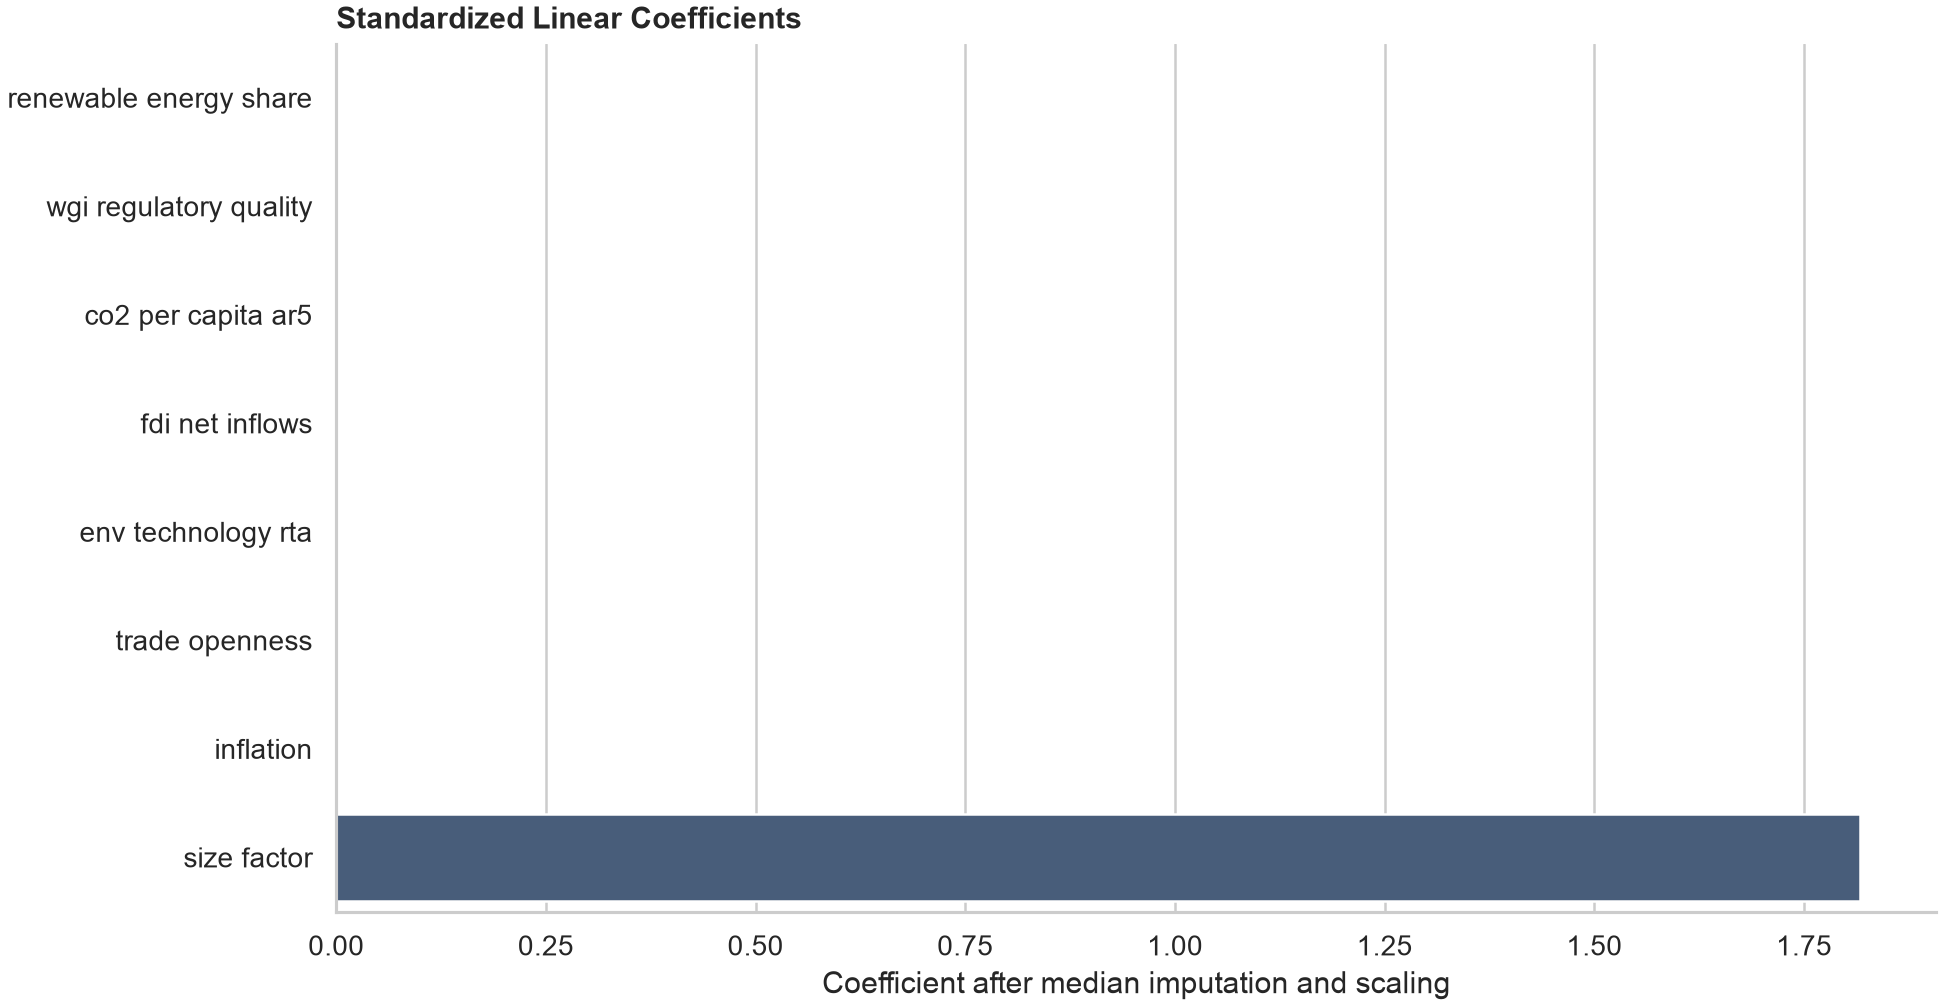

In [18]:
display(results['coefficients'])
show_figure('coefficients')

## Step 15: Main Model Versus Mechanism Submodels

The project requirement asks for interpretable prediction and substantive interpretation. The main v2 model remains the primary specification because it has the broadest balanced set of literature-backed predictors. The mechanism submodels ask narrower questions: whether RISE energy regulation, R&D/co-invention/tax capacity, or OECD EPS carry predictive signal in their own available panels.

The comparison below is an own-sample diagnostic. It is useful for understanding mechanisms, but it is not a direct ranking because the submodel panels have different countries and test years.


,panel_id,panel_label,panel_role,target_column,lag_suffix,best_model,feature_columns,rows,countries,train_year_start,...,test_year_start,test_year_end,validation_mae,validation_rmse,test_mae,test_rmse,test_oos_r2_vs_train_mean,test_spearman,n_test,comparison_scope
0,main,Main v2 model,main,env_patent_share_inventions,lag1_3_mean,lasso_alpha_1,8,2612,174,1999,...,2021,2023,0.836675,1.822312,1.063462,2.404000,0.662288,0.845875,312,own_sample_not_direct_ranking
1,suba,Submodel A: RISE and high-tech exports,mechanism_submodel,env_patent_share_inventions,lag1_3_mean,lasso_alpha_1,3,1031,128,2013,...,2022,2023,1.658056,3.956128,1.753245,4.719538,0.000044,NaN,173,own_sample_not_direct_ranking
2,subb,"Submodel B: R&D, co-invention, and tax",mechanism_submodel,env_patent_share_inventions,lag1_3_mean,lasso_alpha_1,5,2352,119,1999,...,2021,2023,1.421842,3.080681,1.616453,3.993326,0.147197,0.660685,284,own_sample_not_direct_ranking
3,subc,Submodel C: OECD EPS,mechanism_submodel,env_patent_share_inventions,lag1_3_mean,lasso_alpha_1,1,1154,40,1993,...,2018,2021,3.379572,5.238619,3.394938,5.298908,0.005631,0.418387,160,own_sample_not_direct_ranking


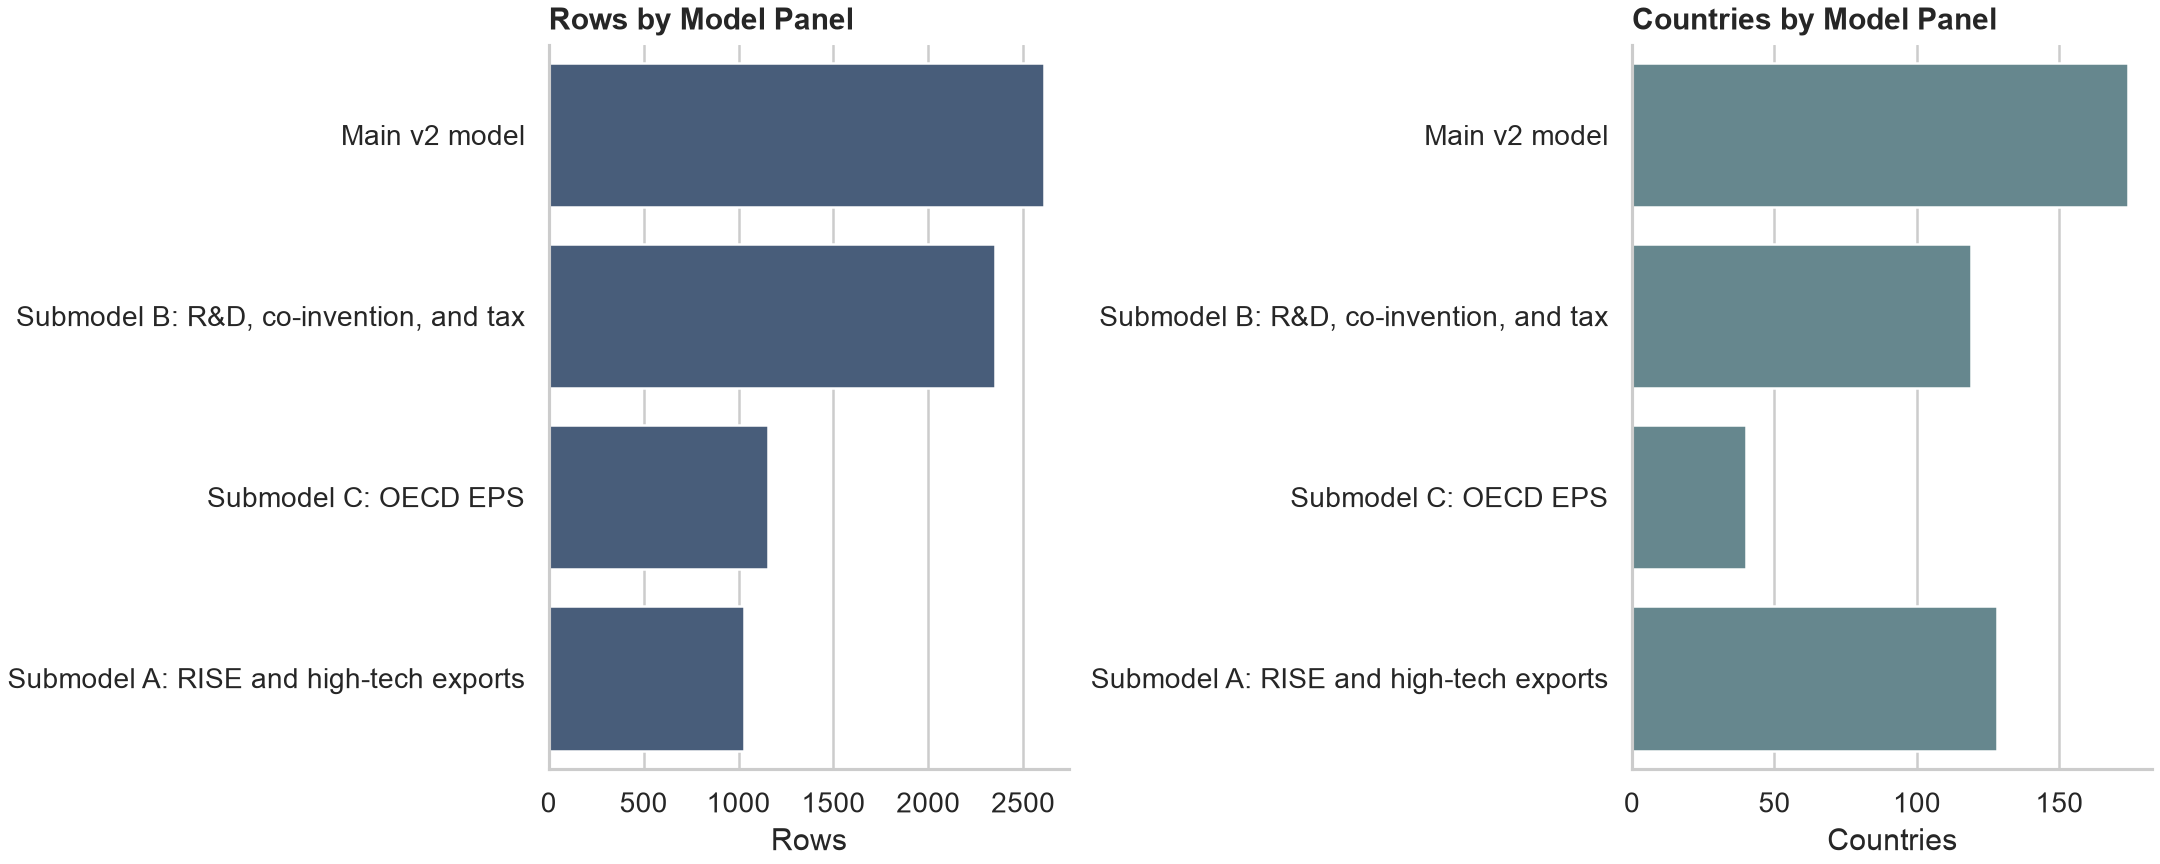

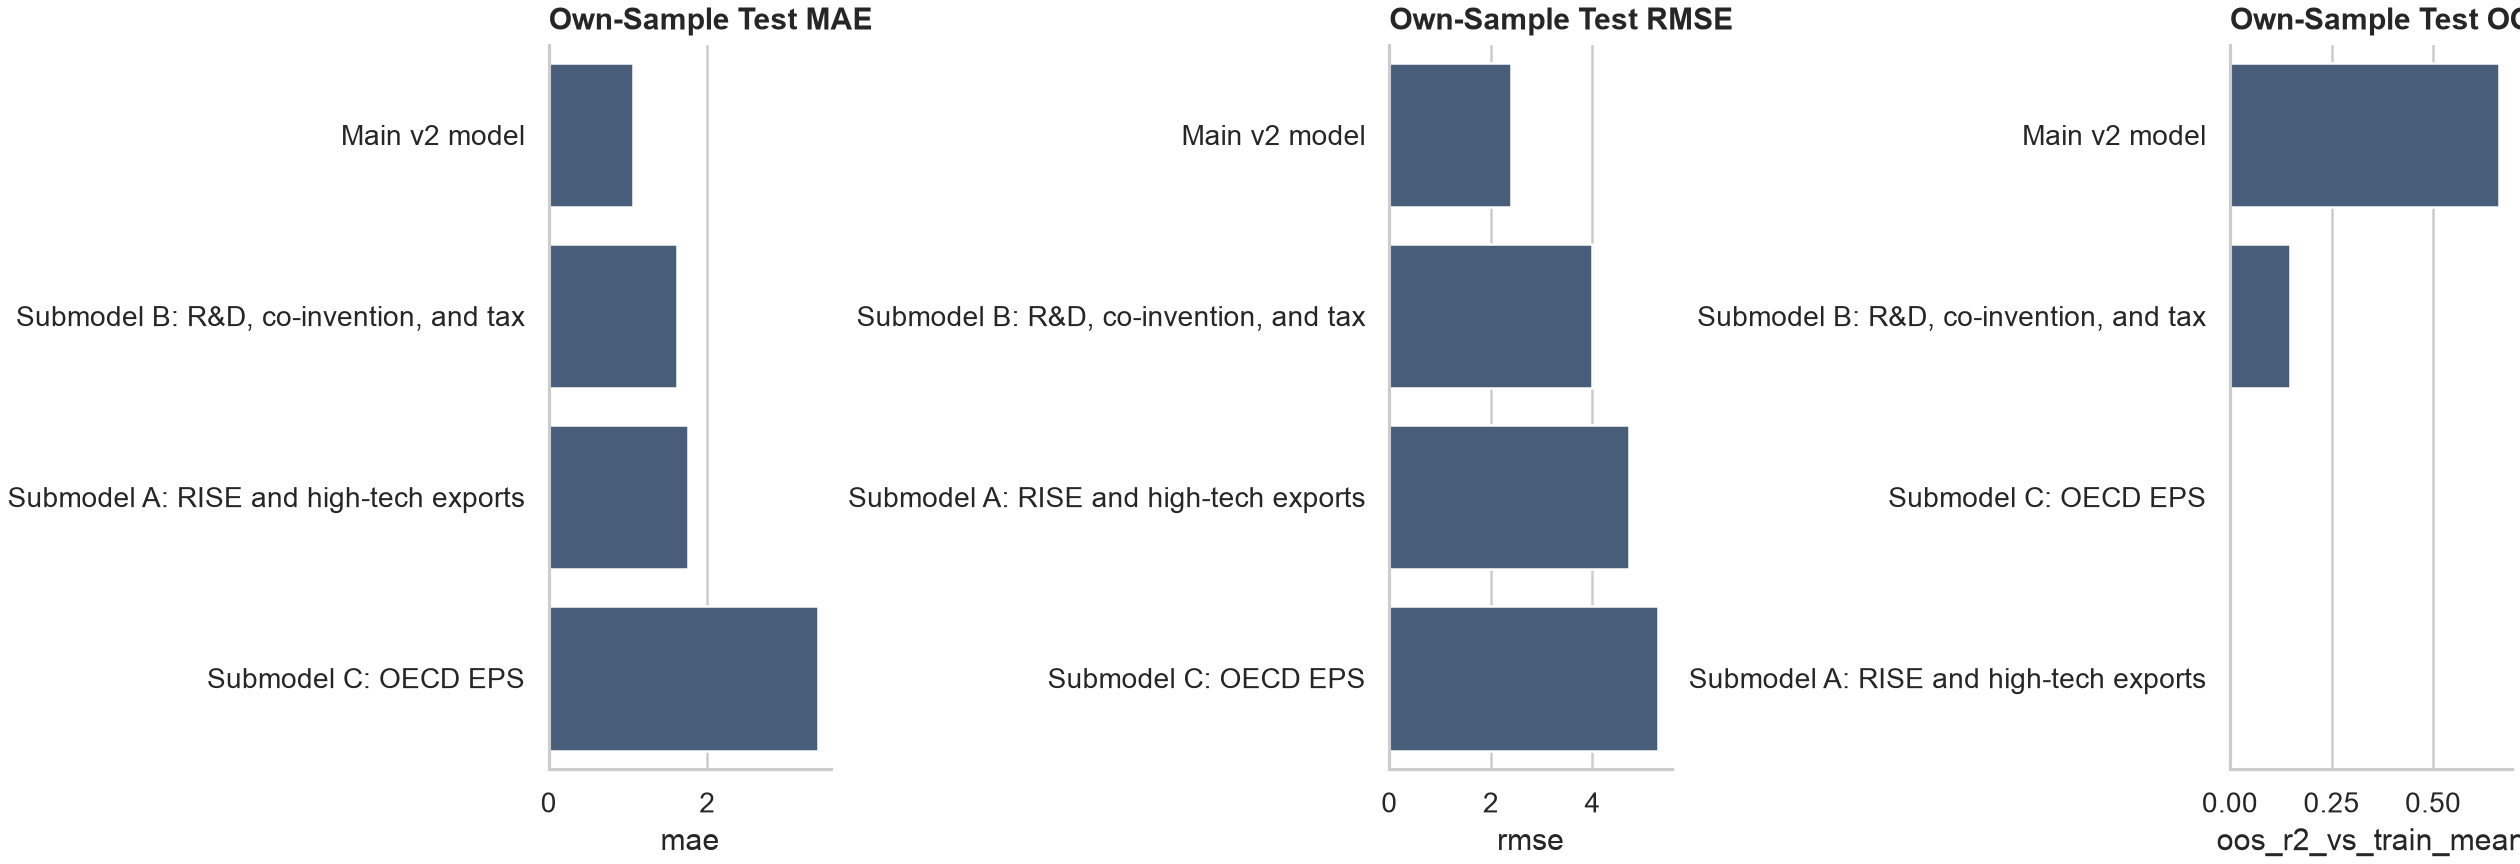

In [19]:
panel_comparison = results['panel_comparison']
display(panel_comparison)
show_figure('panel_sample_comparison')
show_figure('test_metric_comparison')


## Step 16: Same-Sample Nested Submodel Tests

The pure submodel table above is useful descriptively, but it is not the main comparability test. For comparability, each submodel sample is evaluated twice on exactly the same country-year rows: first with only the main-model predictors, then with the main predictors plus the submodel predictors. The delta column below is the augmented model's test MAE minus the same-sample main-controls baseline; negative values mean the submodel variables improve MAE.

In the current run, none of the submodel augmentations improves primary test MAE. This is a negative result for incremental predictive value, not evidence that the mechanisms are unimportant causally.


,comparison_group,rows,countries,baseline_validation_mae,augmented_validation_mae,delta_validation_mae_augmented_minus_baseline,baseline_test_mae,augmented_test_mae,delta_test_mae_augmented_minus_baseline,improves_primary_test_mae
0,suba,1012,124,1.002396,1.002396,0.000000,1.186003,1.186003,0.000000,False
1,subb,2190,109,0.997790,0.967669,-0.030121,1.231084,1.243716,0.012632,False
2,subc,918,40,1.871912,2.001309,0.129397,1.932728,2.031772,0.099045,False


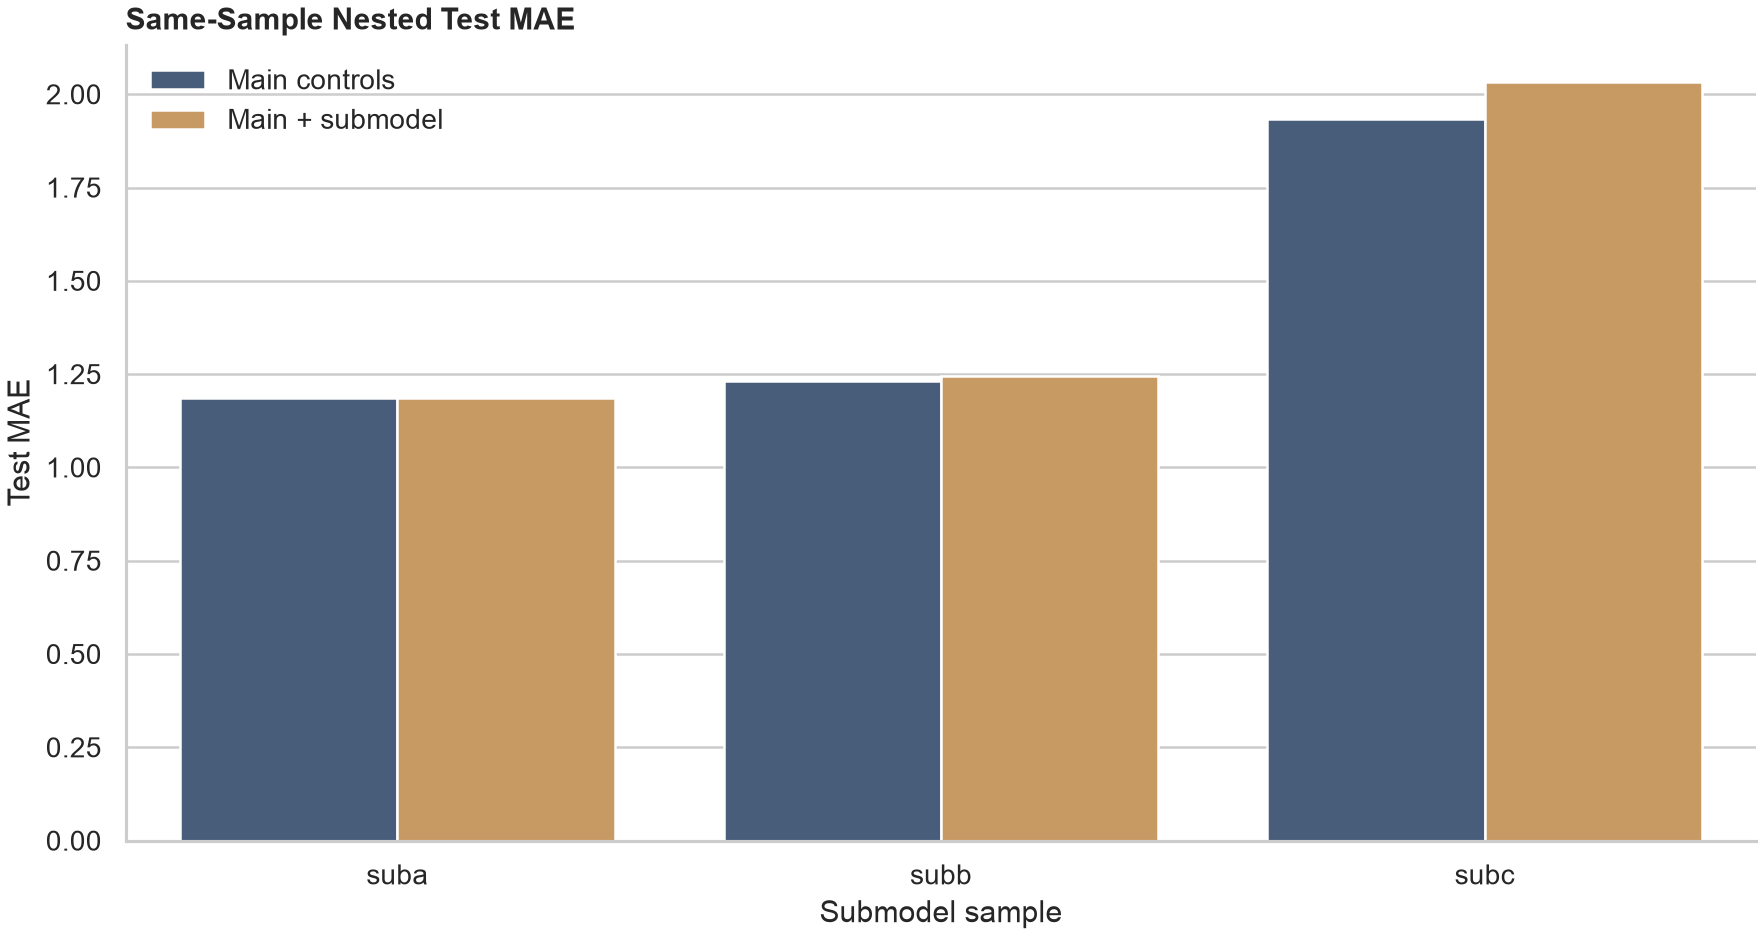

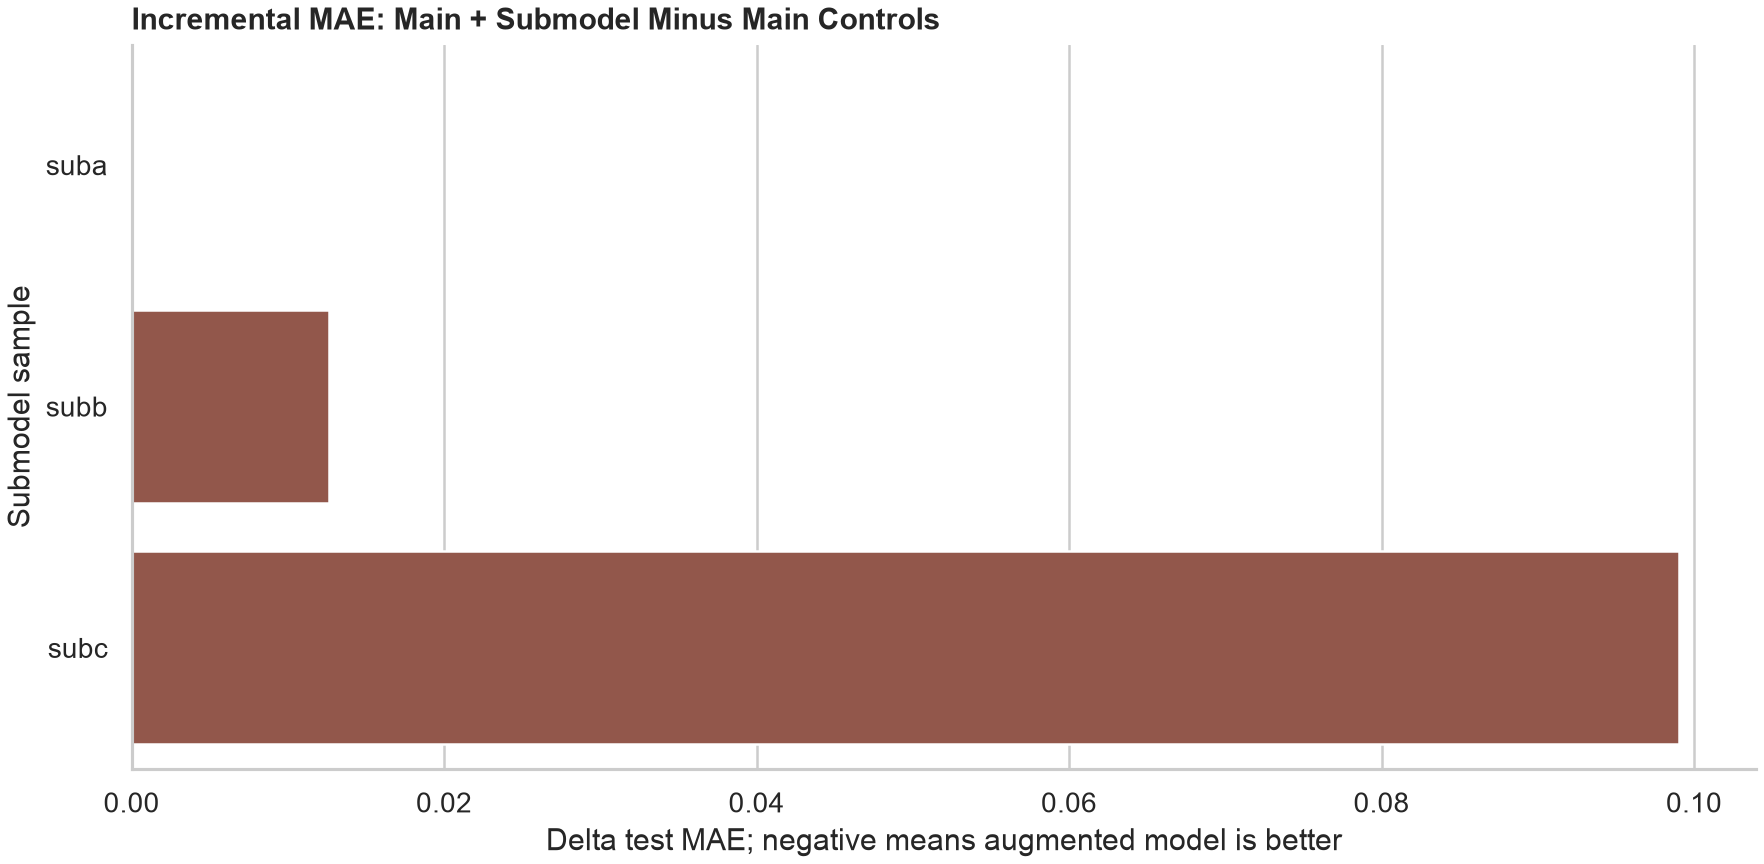

In [20]:
nested_comparison = results['nested_comparison']
display(
    nested_comparison[[
        'comparison_group',
        'rows',
        'countries',
        'baseline_validation_mae',
        'augmented_validation_mae',
        'delta_validation_mae_augmented_minus_baseline',
        'baseline_test_mae',
        'augmented_test_mae',
        'delta_test_mae_augmented_minus_baseline',
        'improves_primary_test_mae',
    ]]
)
show_figure('nested_test_mae_comparison')
show_figure('nested_test_mae_delta')


## Step 17: Compact Submodel Coefficient Check

Submodel coefficients are a secondary diagnostic. To keep the notebook focused, we show a compact table rather than another coefficient figure. A nonzero coefficient means that the narrow mechanism panel used that feature for prediction, not that the feature causally caused later environmental patenting.


,panel_id,panel_label,model,feature,coefficient,abs_coefficient
0,main,Main v2 model,lasso_alpha_1,size_factor_lag1_3_mean,1.817162,1.817162
1,main,Main v2 model,lasso_alpha_1,renewable_energy_share_lag1_3_mean,-0.000000,0.000000
2,main,Main v2 model,lasso_alpha_1,wgi_regulatory_quality_lag1_3_mean,0.000000,0.000000
3,main,Main v2 model,lasso_alpha_1,co2_per_capita_ar5_lag1_3_mean,0.000000,0.000000
8,suba,Submodel A: RISE and high-tech exports,lasso_alpha_1,rise_energy_efficiency_lag1_3_mean,0.000000,0.000000
9,suba,Submodel A: RISE and high-tech exports,lasso_alpha_1,rise_renewable_energy_lag1_3_mean,0.000000,0.000000
10,suba,Submodel A: RISE and high-tech exports,lasso_alpha_1,high_tech_exports_lag1_3_mean,0.000000,0.000000
11,subb,"Submodel B: R&D, co-invention, and tax",lasso_alpha_1,rd_expenditure_gdp_lag1_3_mean,0.968091,0.968091
12,subb,"Submodel B: R&D, co-invention, and tax",lasso_alpha_1,env_co_invention_share_lag1_3_mean,0.000000,0.000000
13,subb,"Submodel B: R&D, co-invention, and tax",lasso_alpha_1,energy_imports_net_lag1_3_mean,0.000000,0.000000


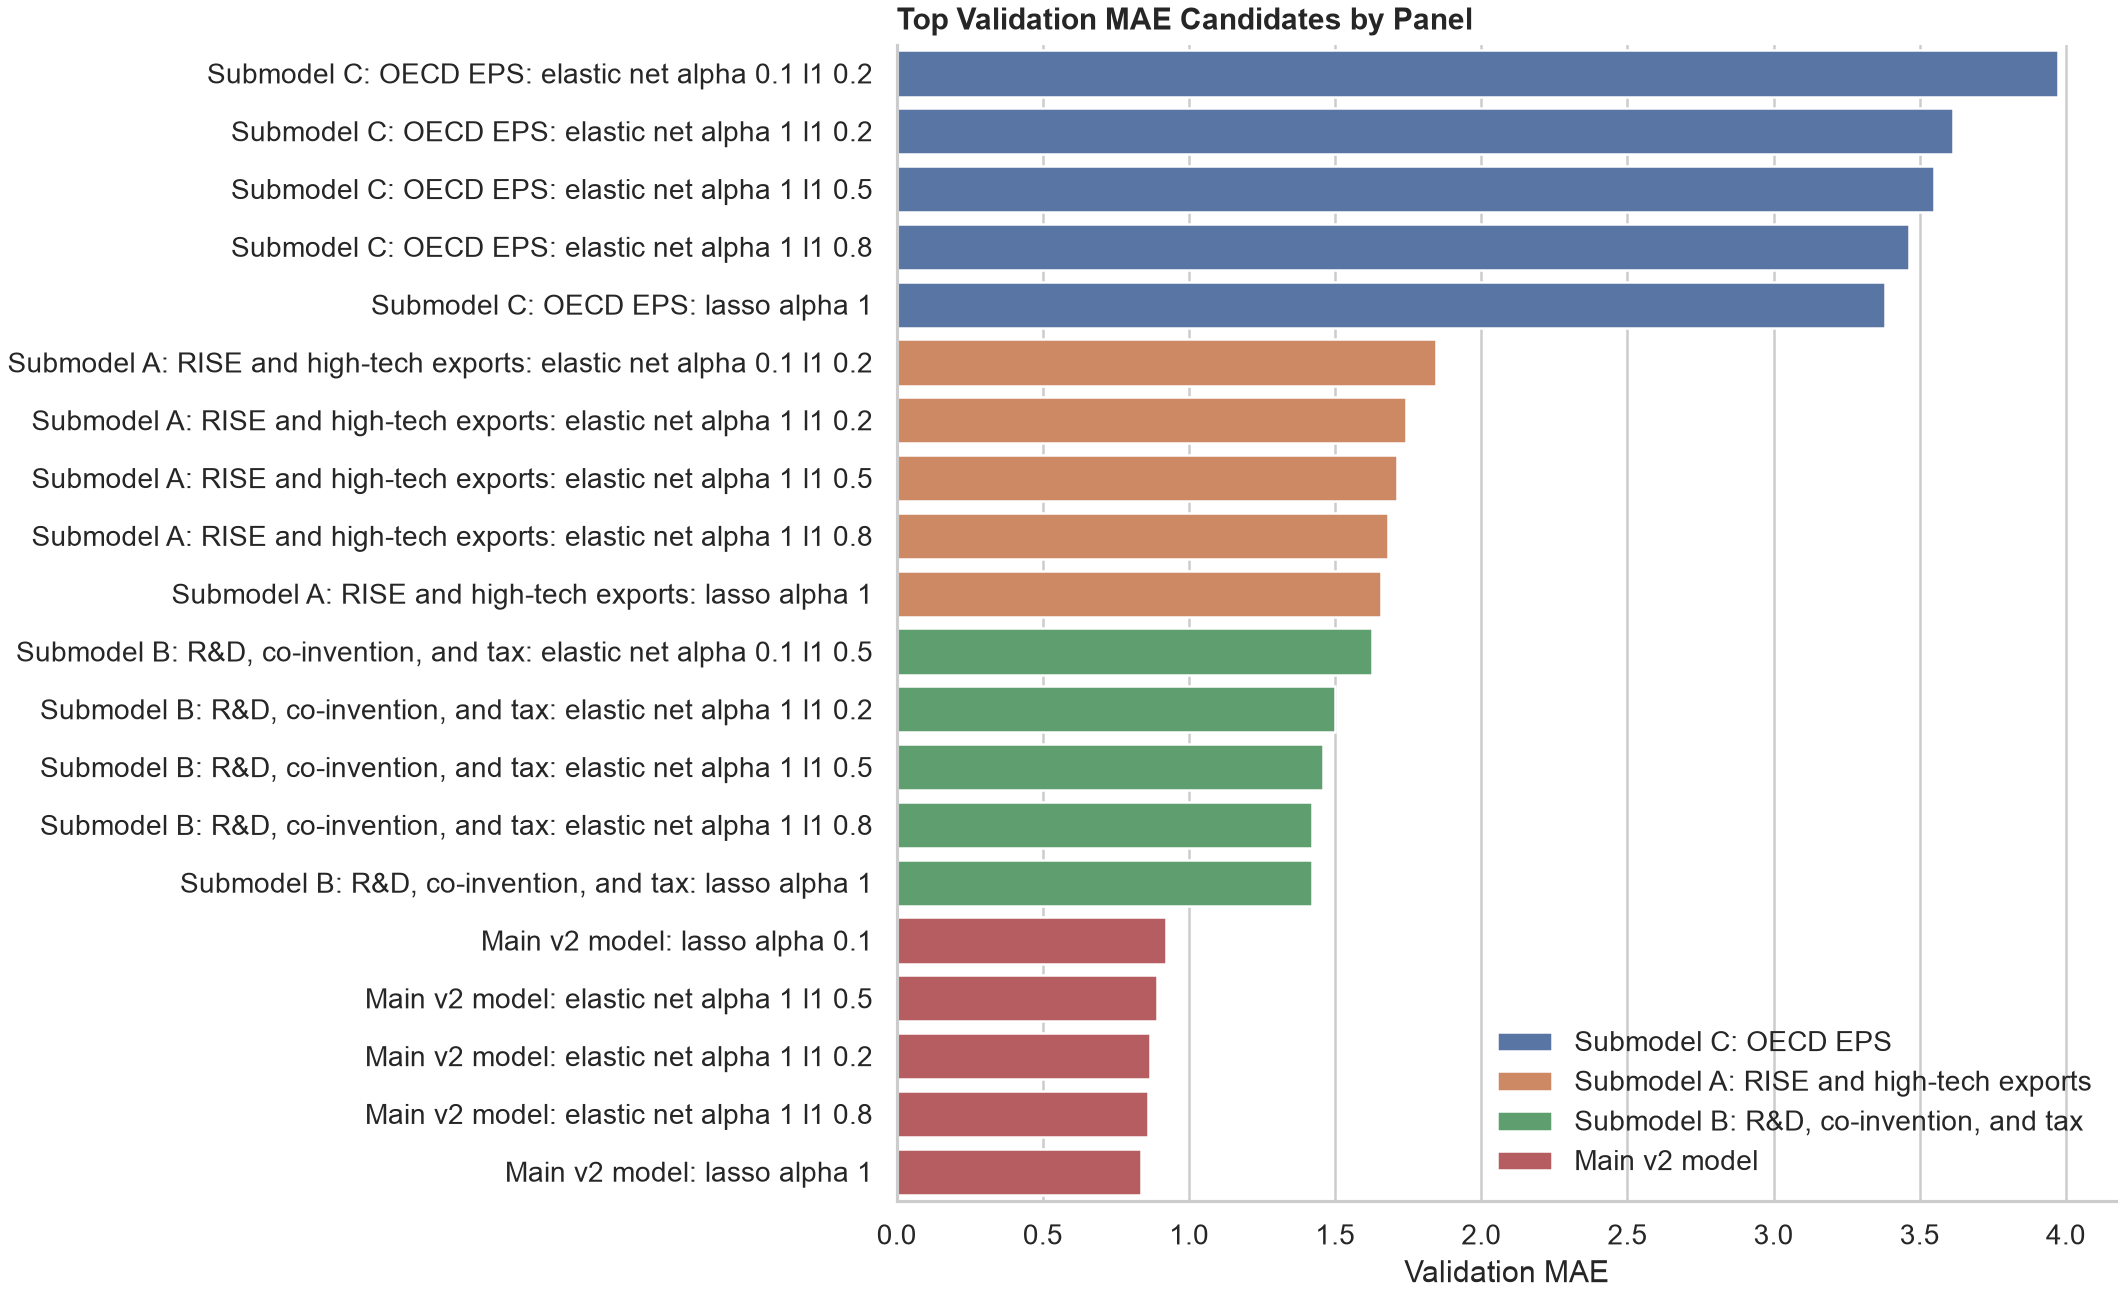

In [21]:
display(
    results['panel_coefficients']
    .sort_values(['panel_id', 'abs_coefficient'], ascending=[True, False])
    .groupby('panel_id', as_index=False, group_keys=False)
    .head(4)
    .loc[:, ['panel_id', 'panel_label', 'model', 'feature', 'coefficient', 'abs_coefficient']]
)
show_figure('panel_validation_mae')


## Step 18: ElasticNet Under Correlated Predictors

ElasticNet is useful here because country-level predictors are correlated. The diagnostics use train plus validation rows only, so the final test labels do not influence interpretation. The correlation tables are computed on the same imputed and scaled train+validation design matrix used by the fitted pipeline when available. Zero ElasticNet coefficients are marked as `shrunk_to_zero` rather than treated as sign-aligned.

These tables explain coefficient stability and overlap among predictors; they are not a post-test rule for dropping variables.


Correlation diagnostics use train+validation years 1999-2020 with n=2300 rows. Design: `imputed_scaled_train_validation_design`.

,panel_id,panel_label,method,feature_a,feature_b,correlation,abs_correlation
0,main,Main v2 model,spearman,fdi_net_inflows_lag1_3_mean,size_factor_lag1_3_mean,0.757800,0.757800
1,main,Main v2 model,spearman,renewable_energy_share_lag1_3_mean,co2_per_capita_ar5_lag1_3_mean,-0.605711,0.605711
2,main,Main v2 model,spearman,wgi_regulatory_quality_lag1_3_mean,co2_per_capita_ar5_lag1_3_mean,0.548990,0.548990
3,main,Main v2 model,spearman,co2_per_capita_ar5_lag1_3_mean,size_factor_lag1_3_mean,0.488150,0.488150
4,main,Main v2 model,spearman,wgi_regulatory_quality_lag1_3_mean,inflation_lag1_3_mean,-0.452890,0.452890
5,main,Main v2 model,spearman,co2_per_capita_ar5_lag1_3_mean,fdi_net_inflows_lag1_3_mean,0.451581,0.451581
6,main,Main v2 model,spearman,wgi_regulatory_quality_lag1_3_mean,fdi_net_inflows_lag1_3_mean,0.394467,0.394467
7,main,Main v2 model,spearman,wgi_regulatory_quality_lag1_3_mean,size_factor_lag1_3_mean,0.360427,0.360427
8,main,Main v2 model,spearman,co2_per_capita_ar5_lag1_3_mean,inflation_lag1_3_mean,-0.349558,0.349558
9,main,Main v2 model,spearman,wgi_regulatory_quality_lag1_3_mean,trade_openness_lag1_3_mean,0.322879,0.322879


,panel_id,panel_label,method,feature,target,non_missing_rows,correlation,abs_correlation
0,main,Main v2 model,spearman,size_factor_lag1_3_mean,env_patent_share_inventions,2300,0.854383,0.854383
1,main,Main v2 model,spearman,fdi_net_inflows_lag1_3_mean,env_patent_share_inventions,2300,0.704948,0.704948
2,main,Main v2 model,spearman,co2_per_capita_ar5_lag1_3_mean,env_patent_share_inventions,2300,0.601469,0.601469
3,main,Main v2 model,spearman,wgi_regulatory_quality_lag1_3_mean,env_patent_share_inventions,2300,0.515764,0.515764
4,main,Main v2 model,spearman,inflation_lag1_3_mean,env_patent_share_inventions,2300,-0.295213,0.295213
5,main,Main v2 model,spearman,renewable_energy_share_lag1_3_mean,env_patent_share_inventions,2300,-0.243561,0.243561
6,main,Main v2 model,spearman,env_technology_rta_lag1_3_mean,env_patent_share_inventions,2300,-0.184188,0.184188
7,main,Main v2 model,spearman,trade_openness_lag1_3_mean,env_patent_share_inventions,2300,-0.061258,0.061258


,panel_id,panel_label,panel_role,comparison_group,feature_set_role,target_column,lag_suffix,model,feature,coefficient,abs_coefficient,target_correlation,abs_target_correlation,target_correlation_rows,coefficient_sign,target_correlation_sign,coefficient_status,sign_aligned
0,main,Main v2 model,main,None,None,env_patent_share_inventions,lag1_3_mean,lasso_alpha_1,size_factor_lag1_3_mean,1.817162,1.817162,0.854383,0.854383,2300,1,1,nonzero,True
1,main,Main v2 model,main,None,None,env_patent_share_inventions,lag1_3_mean,lasso_alpha_1,renewable_energy_share_lag1_3_mean,-0.000000,0.000000,-0.243561,0.243561,2300,0,-1,shrunk_to_zero,False
2,main,Main v2 model,main,None,None,env_patent_share_inventions,lag1_3_mean,lasso_alpha_1,wgi_regulatory_quality_lag1_3_mean,0.000000,0.000000,0.515764,0.515764,2300,0,1,shrunk_to_zero,False
3,main,Main v2 model,main,None,None,env_patent_share_inventions,lag1_3_mean,lasso_alpha_1,co2_per_capita_ar5_lag1_3_mean,0.000000,0.000000,0.601469,0.601469,2300,0,1,shrunk_to_zero,False
4,main,Main v2 model,main,None,None,env_patent_share_inventions,lag1_3_mean,lasso_alpha_1,fdi_net_inflows_lag1_3_mean,0.000000,0.000000,0.704948,0.704948,2300,0,1,shrunk_to_zero,False
5,main,Main v2 model,main,None,None,env_patent_share_inventions,lag1_3_mean,lasso_alpha_1,env_technology_rta_lag1_3_mean,-0.000000,0.000000,-0.184188,0.184188,2300,0,-1,shrunk_to_zero,False
6,main,Main v2 model,main,None,None,env_patent_share_inventions,lag1_3_mean,lasso_alpha_1,trade_openness_lag1_3_mean,-0.000000,0.000000,-0.061258,0.061258,2300,0,-1,shrunk_to_zero,False
7,main,Main v2 model,main,None,None,env_patent_share_inventions,lag1_3_mean,lasso_alpha_1,inflation_lag1_3_mean,-0.000000,0.000000,-0.295213,0.295213,2300,0,-1,shrunk_to_zero,False


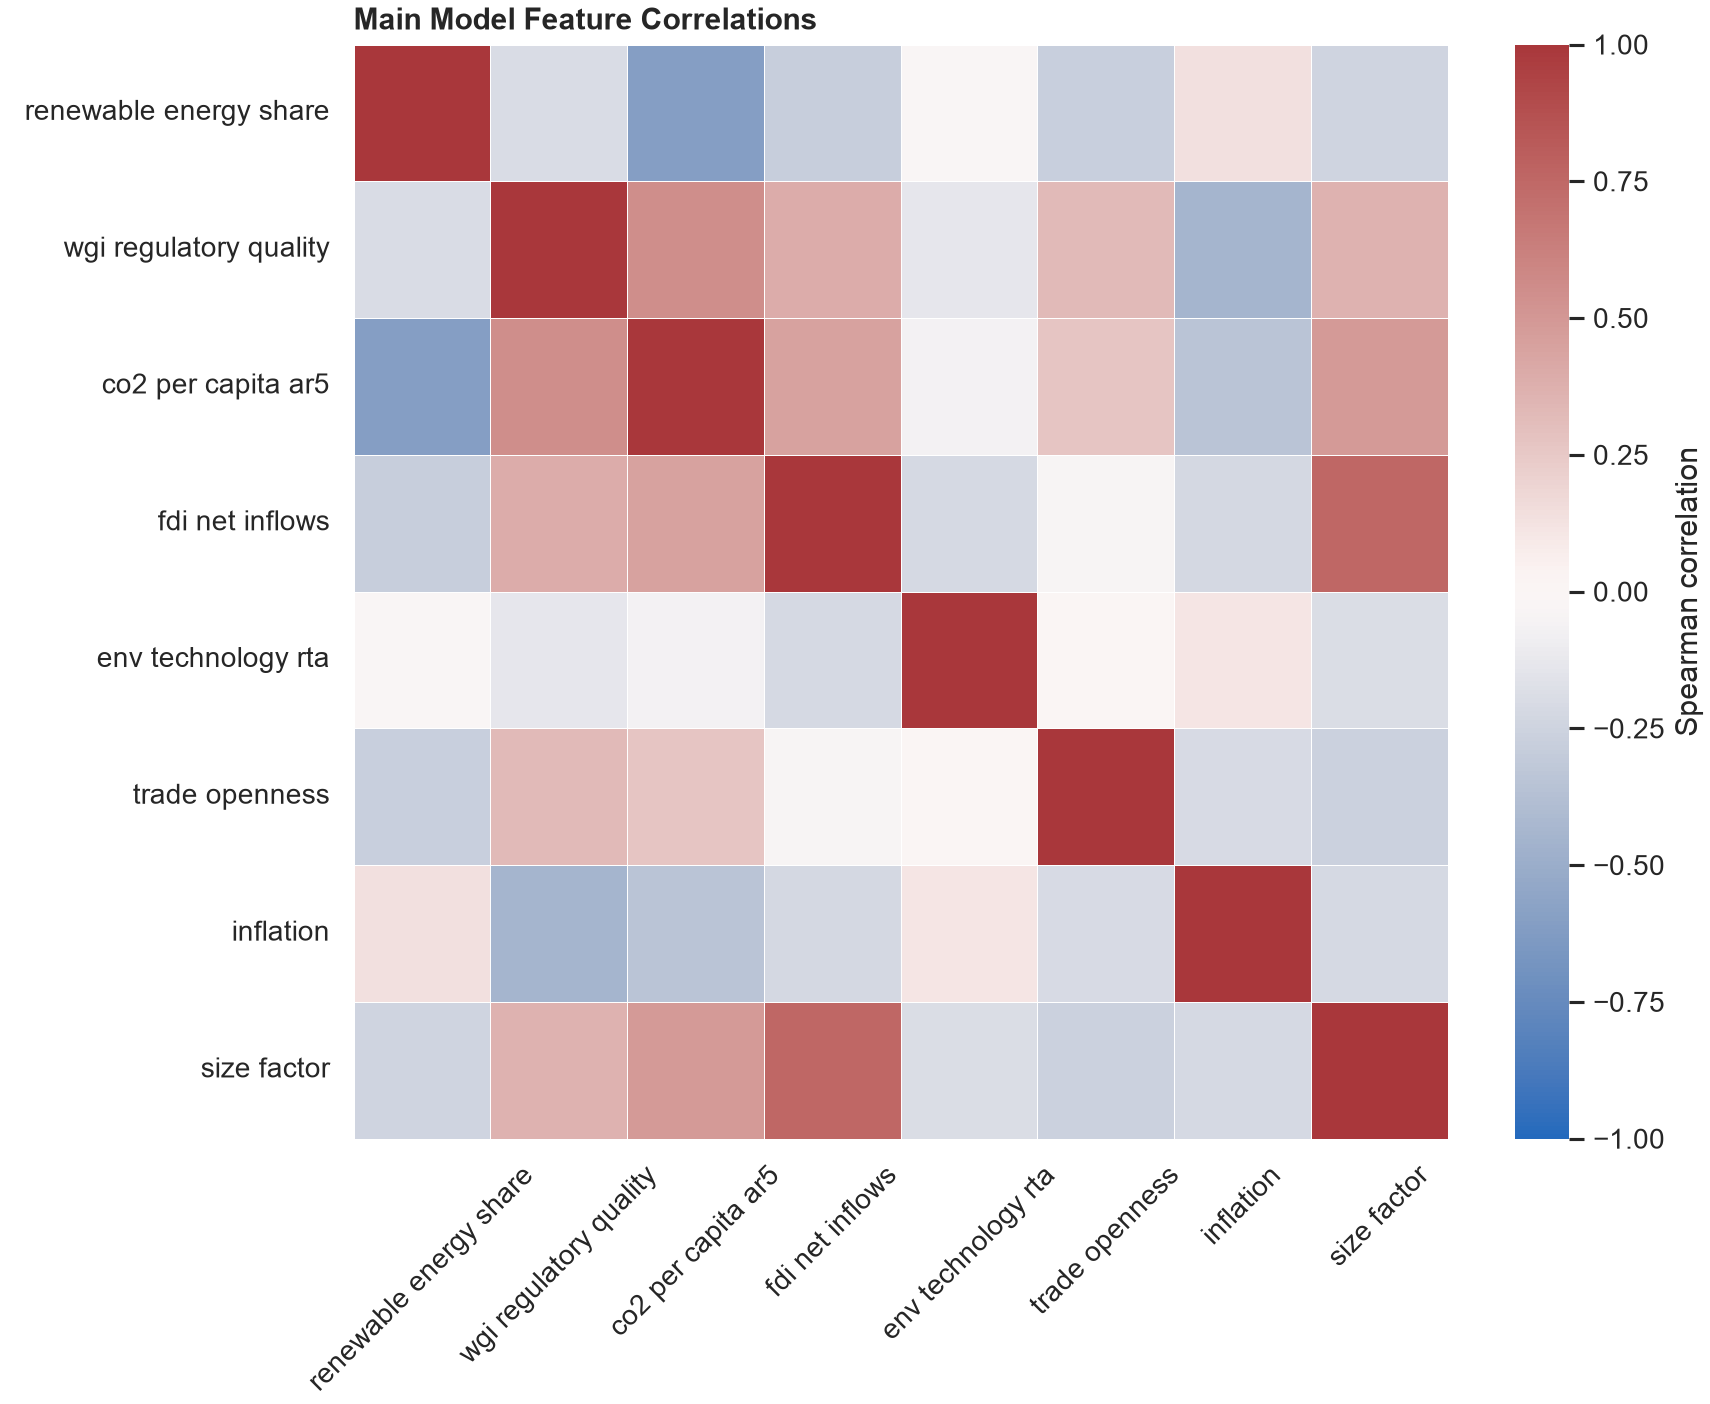

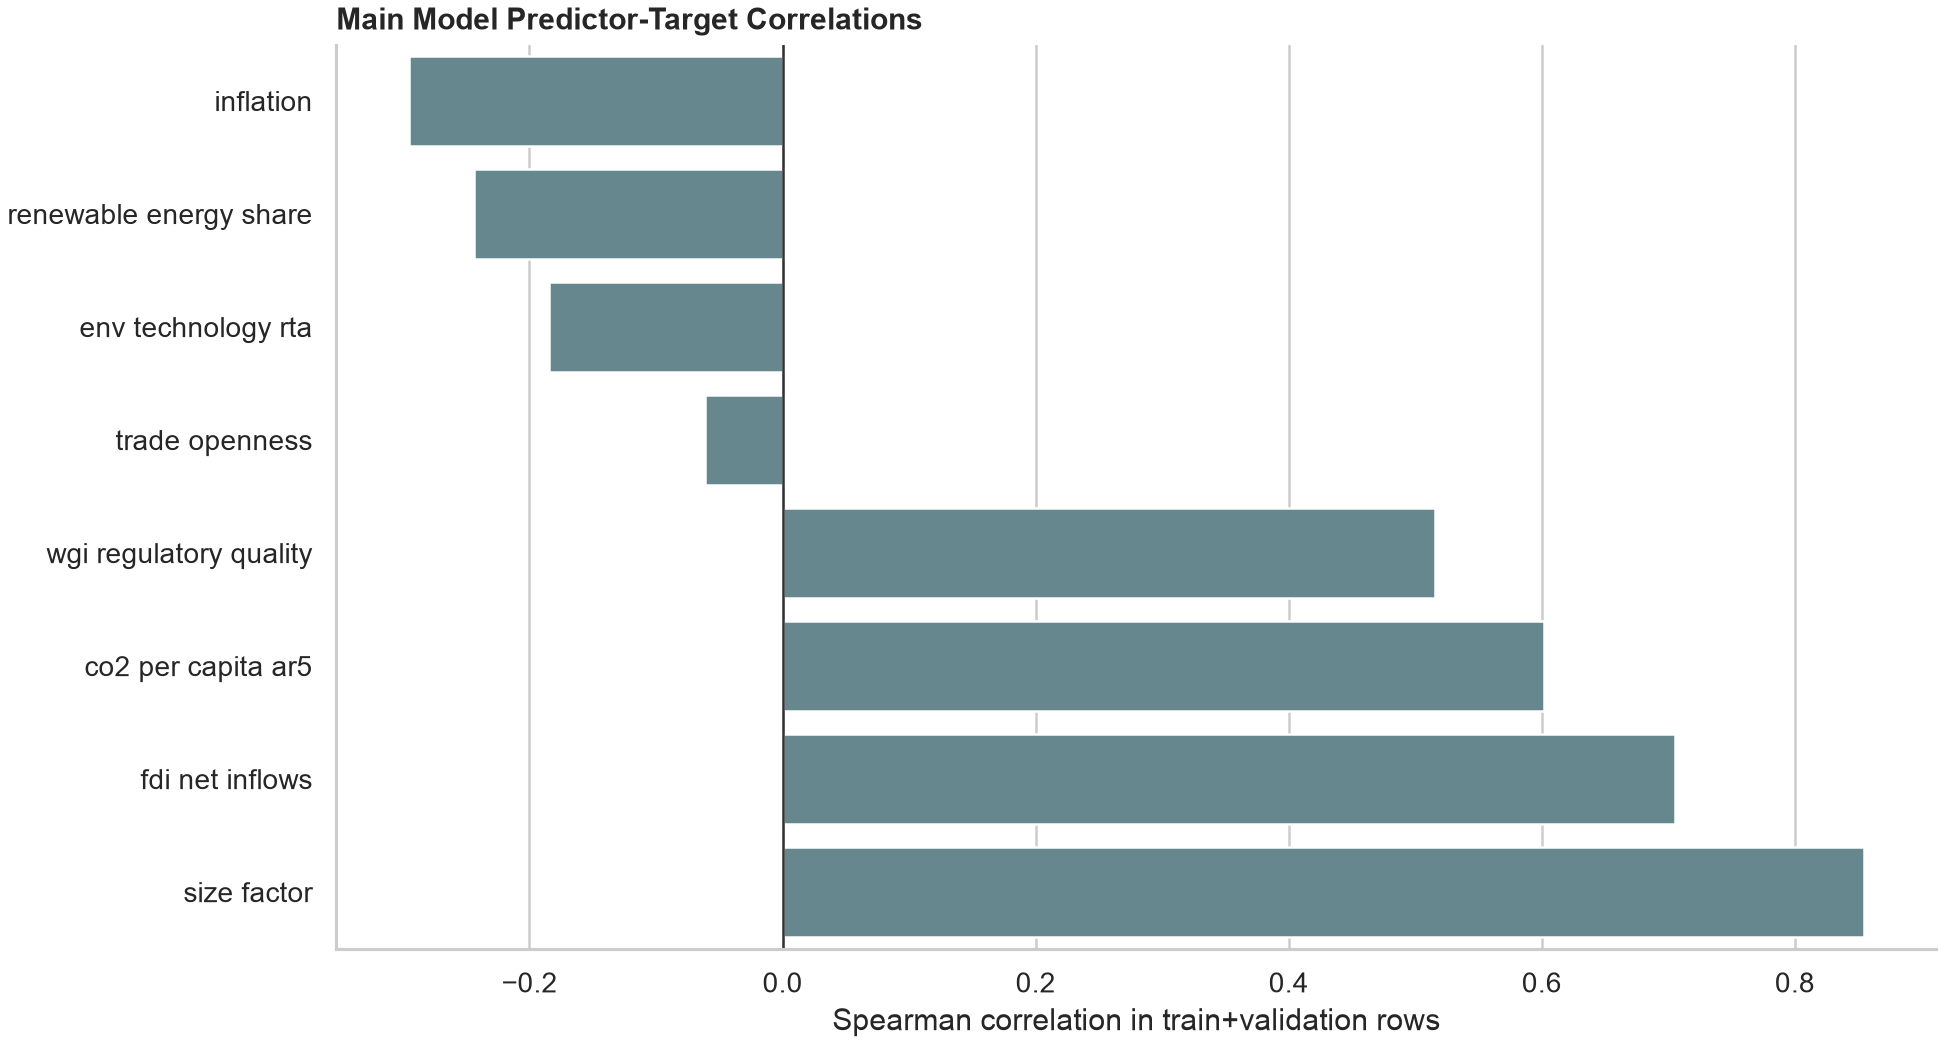

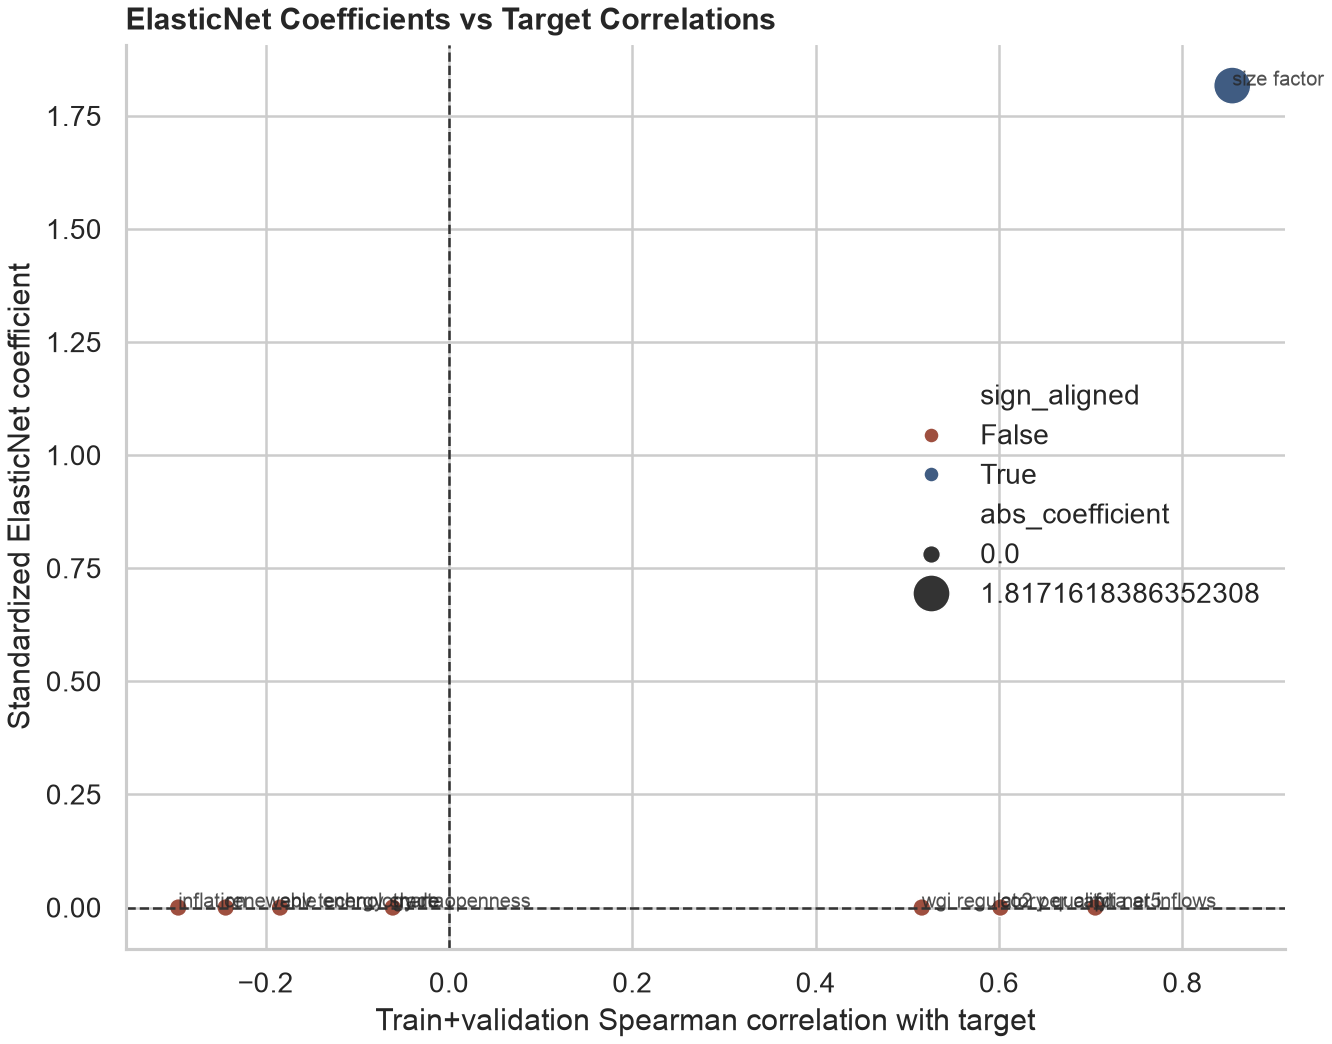

In [22]:
diagnostics = results['correlation_diagnostics']
display(Markdown(
    f"Correlation diagnostics use train+validation years "
    f"{diagnostics['analysis_year_start']}-{diagnostics['analysis_year_end']} "
    f"with n={diagnostics['analysis_rows']} rows. "
    f"Design: `{diagnostics['correlation_design']}`."
))
display(diagnostics['top_correlated_pairs'])
display(diagnostics['target_correlations'])
display(diagnostics['coefficient_correlation_alignment'])
show_figure('main_feature_correlation_heatmap')
show_figure('main_target_correlations')
show_figure('main_coefficient_correlation_alignment')


## Output Files

The script writes reusable CSV outputs under `3_models/outputs/` and figure files under `4_analysis/figures/modeling/`. These files include the main linear model, historical baselines, failure-mode errors, missingness sensitivity, pure submodel diagnostics, same-sample nested tests, and correlation diagnostics.


In [23]:
pd.DataFrame(
    [{'artifact': name, 'path': str(path)} for name, path in results['outputs'].items()]
)

,artifact,path
0,sample_summary,/Users/jiesong/Documents/GitHub/env-innovation...
1,specification_registry,/Users/jiesong/Documents/GitHub/env-innovation...
2,validation_metrics,/Users/jiesong/Documents/GitHub/env-innovation...
3,test_metrics,/Users/jiesong/Documents/GitHub/env-innovation...
4,predictions,/Users/jiesong/Documents/GitHub/env-innovation...
5,coefficients,/Users/jiesong/Documents/GitHub/env-innovation...
6,panel_sample_summary,/Users/jiesong/Documents/GitHub/env-innovation...
7,panel_validation_metrics,/Users/jiesong/Documents/GitHub/env-innovation...
8,panel_test_metrics,/Users/jiesong/Documents/GitHub/env-innovation...
9,panel_predictions,/Users/jiesong/Documents/GitHub/env-innovation...


## Artifact Completeness Check

This final cell makes the notebook self-checking without embedding verification logic in the notebook. It calls `verify_generated_artifacts()` from `run_modeling.py`, so artifact validation is reusable from tests or terminal runs as well.


In [24]:
artifact_check = verify_generated_artifacts(
    results=results,
    run_started_at=run_started_at,
    project_root=PROJECT_ROOT,
)
artifact_count_summary = artifact_check['artifact_count_summary']
artifact_suffix_summary = artifact_check['artifact_suffix_summary']
display(artifact_count_summary)
display(artifact_suffix_summary)
display(Markdown(
    f"Generated artifact check passed: {int(artifact_count_summary.loc[artifact_count_summary['check'].eq('verified_files'), 'count'].iloc[0])} files verified."
))


,check,count
0,registered_outputs,49
1,indexed_figures,22
2,verified_files,93


,suffix,files,bytes
0,.csv,48,1836779
1,.md,1,17085
2,.pdf,22,503775
3,.png,22,1748796


Generated artifact check passed: 93 files verified.